## Команда Correlation Queens

## Параметры решения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({'figure.figsize': (9, 4.5), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

REQUIRED = ['users.csv', 'sessions.csv', 'experiment_assignments.csv', 'impressions.csv',
            'clicks.csv', 'orders.csv', 'products.csv', 'sellers.csv',
            'premium_subscriptions.csv', 'support_tickets.csv']

DATA = None
for cand in dict.fromkeys([Path.cwd(), *[p.parent for p in Path.cwd().rglob('sessions.csv')]]):
    if all((cand / f).exists() for f in REQUIRED):
        DATA = cand
        break
if DATA is None:
    raise FileNotFoundError('Не найдена папка с CSV. Укажите путь вручную.')
print('Данные читаем из:', DATA)

EXP_START = pd.Timestamp('2026-07-01')
EXP_END   = pd.Timestamp('2026-07-30')
OBS_DAYS  = 30


P = {
    'ai_inference_rub_per_exposed_30d': 1.20,
    'return_handling_rub':              700.0, 
    'support_ticket_rub':               350.0,
    'support_free_tickets_per_100k':    250.0,
    'tech_capacity_share':              0.60,
    'min_holdout_share':                0.10,
    'horizon_weeks':                    8,
    'returns_maturity_days':            30,
    'guardrail_returns_per_100k':       650.0,
    'guardrail_tickets_per_100k':       300.0,
    'fairness_age_ratio':               0.70,
    'alpha':                            0.05,
    'n_boot':                           6000,
    'seed':                             20260826,
}
P['scale_to_horizon'] = P['horizon_weeks'] * 7 / OBS_DAYS

print(f"Горизонт решения: {P['horizon_weeks']} недель")
print(f"Коэффициент линейного масштабирования 56/30: {P['scale_to_horizon']:.6f}")

Данные читаем из: /Users/alisa/Downloads/Хакатон_The_experts_2026/drive-download-20260827T093926Z-1-001
Горизонт решения: 8 недель
Коэффициент линейного масштабирования 56/30: 1.866667


## 1. Модель принятия решения (Decision model, 7.1)

### 1.1 Основная когорта, единица анализа и правила обработки данных

От состава когорты зависят знаменатель чистого вклада (Net Contribution), техническая емкость первой волны и размер контрольной подвыборки (holdout).

**Единица анализа, пользователь.** Эксперимент рандомизирован по `user_id`, поэтому независимым наблюдением считаем пользователя, а не отдельный показ, клик или заказ.

**Основная когорта, подходящий активный пользователь (eligible active user).** В нее входит пользователь с одним непротиворечивым назначением в эксперимент и хотя бы одной сессией в период с 1 по 30 июля. Условие активности важно, потому что техническая емкость задана как доля активной аудитории.

**Экспозиция.** В эксперименте вариант модели применяется ко всем сессиям назначенного пользователя. Поэтому назначение в тестовую группу считаем фактическим воздействием модели. Это допущение отдельно зафиксировано в таблице `assumptions`.

In [2]:
DATE_COLS = {
    'users': ['registration_date'], 'experiment_assignments': ['assignment_date'],
    'sessions': ['session_date'], 'impressions': ['event_time'], 'clicks': ['event_time'],
    'orders': ['order_date', 'return_date'], 'products': ['created_date'],
    'sellers': ['joined_date'], 'premium_subscriptions': ['premium_start_date'],
    'support_tickets': ['ticket_date'],
}
raw = {n: pd.read_csv(DATA / f'{n}.csv', parse_dates=d) for n, d in DATE_COLS.items()}

users, assign, sessions = raw['users'], raw['experiment_assignments'], raw['sessions']
impr, clicks, orders = raw['impressions'], raw['clicks'], raw['orders']
products, sellers = raw['products'], raw['sellers']
premium, tickets = raw['premium_subscriptions'], raw['support_tickets']

per_user = assign.groupby('user_id').agg(назначений=('assignment_id', 'size'),
                                         разных_групп=('experiment_group', 'nunique'))
crossover_users = set(per_user.index[per_user.разных_групп > 1])

bot_users = set(users.loc[users.is_bot_candidate == 1, 'user_id'])
EXCLUDED = crossover_users | bot_users

dup_impr_ids = set(impr.loc[impr.is_duplicate_event == 1, 'impression_id'])

first_assign = (assign.sort_values(['assignment_date', 'assignment_id'])
                      .drop_duplicates('user_id')[['user_id', 'experiment_group']])
assign_c = first_assign[~first_assign.user_id.isin(EXCLUDED)].copy()

users_c    = users[~users.user_id.isin(EXCLUDED)].copy()
sessions_c = sessions[~sessions.user_id.isin(EXCLUDED)].copy()
impr_c     = impr[(~impr.user_id.isin(EXCLUDED)) & (impr.is_duplicate_event == 0)].copy()
clicks_c   = clicks[(~clicks.user_id.isin(EXCLUDED)) &
                    (clicks.impression_id.isin(set(impr_c.impression_id)))].copy()
orders_c   = orders[(~orders.user_id.isin(EXCLUDED)) &
                    (orders.click_id.isin(set(clicks_c.click_id)))].copy()
tickets_c  = tickets[(~tickets.user_id.isin(EXCLUDED)) &
                     (tickets.order_id.isin(set(orders_c.order_id)))].copy()

active_users = set(sessions_c.user_id.unique())
cohort = assign_c[assign_c.user_id.isin(active_users)].copy()
N_ELIGIBLE = len(cohort)

cohort_rules = pd.DataFrame([
    ('Единица рандомизации и анализа', 'пользователь (user_id)',
     'Один человек порождает много показов и заказов, поэтому вся неопределённость считается кластерно по пользователю'),
    ('Primary cohort', 'eligible active user',
     'Ровно одно непротиворечивое назначение и хотя бы одна сессия в окне 1-30 июля'),
    ('Crossover', f'исключены {len(crossover_users)} польз.',
     'Двойное назначение из-за assignment_service_bug, 185 из них реально видели оба варианта'),
    ('Bot-like', f'исключены {len(bot_users)} польз.',
     '0.8% аудитории даёт 8.3% кликов и 0.4% GMV, искажает знаменатели в обеих группах'),
    ('Duplicate events', f'удалены {len(dup_impr_ids)} показов',
     'Строки с is_duplicate_event=1 удаляются по разметке источника вместе с зависимыми кликами и заказами'),
    ('Missing delivery_fee', 'строки сохранены',
     'Механизм близок к MCAR, поле не участвует ни в gross_margin_rub, ни в одной метрике решения'),
    ('Экспозиция', 'exposed = пользователь в тестовом варианте',
     'Вариант применяется ко всем сессиям пользователя, назначение и экспозиция совпадают'),
], columns=['Правило', 'Решение', 'Обоснование'])

kept = pd.DataFrame({
    'До очистки':    [len(users), len(sessions), len(impr), len(clicks), len(orders), len(tickets)],
    'После': [len(users_c), len(sessions_c), len(impr_c), len(clicks_c), len(orders_c), len(tickets_c)],
}, index=['users', 'sessions', 'impressions', 'clicks', 'orders', 'support_tickets'])
kept['Потеряно, %'] = ((1 - kept['После'] / kept['До очистки']) * 100).round(2)

display(cohort_rules)
display(kept)

CAPACITY = int(P['tech_capacity_share'] * N_ELIGIBLE)
print(f'Eligible active users (Знаменатель ёмкости и holdout): {N_ELIGIBLE:,}')
print(cohort.experiment_group.value_counts().rename('пользователей').to_string())
print(f'\nПотолок первой волны: total_exposed <= {P["tech_capacity_share"]:.0%} x {N_ELIGIBLE:,} = {CAPACITY:,}')

,Правило,Решение,Обоснование
0,Единица рандомизации и анализа,пользователь (user_id),Один человек порождает много показов и заказов...
1,Primary cohort,eligible active user,Ровно одно непротиворечивое назначение и хотя ...
2,Crossover,исключены 300 польз.,Двойное назначение из-за assignment_service_bu...
3,Bot-like,исключены 400 польз.,"0.8% аудитории даёт 8.3% кликов и 0.4% GMV, ис..."
4,Duplicate events,удалены 3193 показов,Строки с is_duplicate_event=1 удаляются по раз...
5,Missing delivery_fee,строки сохранены,"Механизм близок к MCAR, поле не участвует ни в..."
6,Экспозиция,exposed = пользователь в тестовом варианте,Вариант применяется ко всем сессиям пользовате...


,До очистки,После,"Потеряно, %"
users,50000,49301,1.4000
sessions,164739,157302,4.5100
impressions,1066434,1015160,4.8100
clicks,91266,82916,9.1500
orders,7407,7302,1.4200
support_tickets,337,333,1.1900


Eligible active users (Знаменатель ёмкости и holdout): 49,301
experiment_group
test       24828
control    24473

Потолок первой волны: total_exposed <= 60% x 49,301 = 29,580


После очистки исключено 1.4 % пользователей и 9.2 % кликов. Заказов стало меньше только на 1.4 %. Большая часть потерянных кликов приходится на пользователей с ботоподобной активностью. Они заметно активнее обычных пользователей, но почти не совершают покупки.

В основной когорте **49 301 подходящий активный пользователь**, из них 24 473 в контрольной группе и 24 828 в тестовой. Все пользователи с корректным назначением имеют хотя бы одну сессию.

Эта аудитория используется как знаменатель для технической емкости и контрольной подвыборки. Максимальный размер первой волны равен **29 580 пользователям**, то есть 60 % основной когорты. Пользователи в контрольной подвыборке в этот лимит не входят.

### 1.2 Зрелость возвратов и обращений в поддержку

Заказ и его последствия наблюдаются не одновременно. Возврат обычно происходит позже покупки, а обращение в поддержку появляется быстрее. Поэтому для корректного сравнения групп нужно одинаковое окно наблюдения.

Если просто обрезать данные календарными границами эксперимента, поздние заказы получат меньше времени на возврат. Это особенно опасно, если в тестовой группе заказов больше.

Для возвратов фиксируем единое окно зрелости **30 дней (D30)**. Для каждого заказа проверяем, был ли возврат в течение 30 дней после покупки. Так ранние и поздние заказы сравниваются на одинаковых условиях.

В первом туре обращения в поддержку были привязаны к дате возврата. Здесь повторно проверяем их относительно даты заказа.

In [3]:
LAST_RETURN_SEEN = orders.return_date.max()
LAST_TICKET_SEEN = tickets.ticket_date.max()

o = orders_c.copy()
o['return_lag_days'] = (o.return_date - o.order_date).dt.days
o['ret_followup']    = (LAST_RETURN_SEEN - o.order_date).dt.days
o['tic_followup']    = (LAST_TICKET_SEEN - o.order_date).dt.days

tk = tickets_c.merge(orders_c[['order_id', 'order_date']], on='order_id', how='left')
tk['ticket_lag_days'] = (tk.ticket_date - tk.order_date).dt.days
TICKET_MAX_LAG = int(tk.ticket_lag_days.max())

maturity_check = pd.DataFrame([
    ('Возвраты', int(o.is_returned.sum()), o.return_lag_days.median(),
     int(o.return_lag_days.max()), int(o.ret_followup.min()),
     'да' if o.ret_followup.min() >= P['returns_maturity_days'] else 'нет'),
    ('Обращения в поддержку', len(tk), tk.ticket_lag_days.median(),
     TICKET_MAX_LAG, int(o.tic_followup.min()),
     'да' if o.tic_followup.min() >= TICKET_MAX_LAG else 'нет'),
], columns=['исход', 'событий', 'медианный лаг, дн', 'макс. лаг, дн',
            'мин. окно наблюдения, дн', 'все заказы зрелые'])
display(maturity_check)

print('Последний заказ  :', o.order_date.max().date())
print('Последний возврат:', LAST_RETURN_SEEN.date())
print('Последний тикет  :', LAST_TICKET_SEEN.date())

immature = o[o.tic_followup < TICKET_MAX_LAG]
rate_last_lag = (tk.ticket_lag_days == TICKET_MAX_LAG).sum() / len(o)
g_imm = immature.merge(cohort, on='user_id').groupby('experiment_group').size()
n_grp = cohort.experiment_group.value_counts()
bias_per_100k = (rate_last_lag * g_imm['test'] / n_grp['test']
                 - rate_last_lag * g_imm['control'] / n_grp['control']) * 1e5

print(f'\nЗаказов с неполным окном для тикетов: {len(immature)} ({len(immature) / len(o) * 100:.2f} %), '
      f'все от {immature.order_date.max().date()}')
print(f'Ожидаемо недосчитано обращений: {rate_last_lag * len(immature):.1f} шт.')
print(f'Смещение оценки прироста обращений: {bias_per_100k:+.1f} на 100 000 пользователей')

,исход,событий,"медианный лаг, дн","макс. лаг, дн","мин. окно наблюдения, дн",все заказы зрелые
0,Возвраты,460,22.0000,37,36,да
1,Обращения в поддержку,333,2.0000,5,4,нет


Последний заказ  : 2026-07-30
Последний возврат: 2026-09-04
Последний тикет  : 2026-08-03

Заказов с неполным окном для тикетов: 242 (3.31 %), все от 2026-07-30
Ожидаемо недосчитано обращений: 1.8 шт.
Смещение оценки прироста обращений: +1.8 на 100 000 пользователей


,Определение возврата,Возвратов,"RR control, %","RR test, %","Разница, п.п.","Относительный рост, %"
0,Обрезка по окну эксперимента (неверно),161,2.0010,2.3550,0.3540,17.6690
1,D7 maturity,58,0.7420,0.8330,0.0900,12.1400
2,D14 maturity,123,1.5490,1.7840,0.2350,15.1430
3,D30 maturity (база решения),352,4.2610,5.2330,0.9720,22.8200
4,Полная история (conservative),460,5.5520,6.8510,1.2990,23.3910


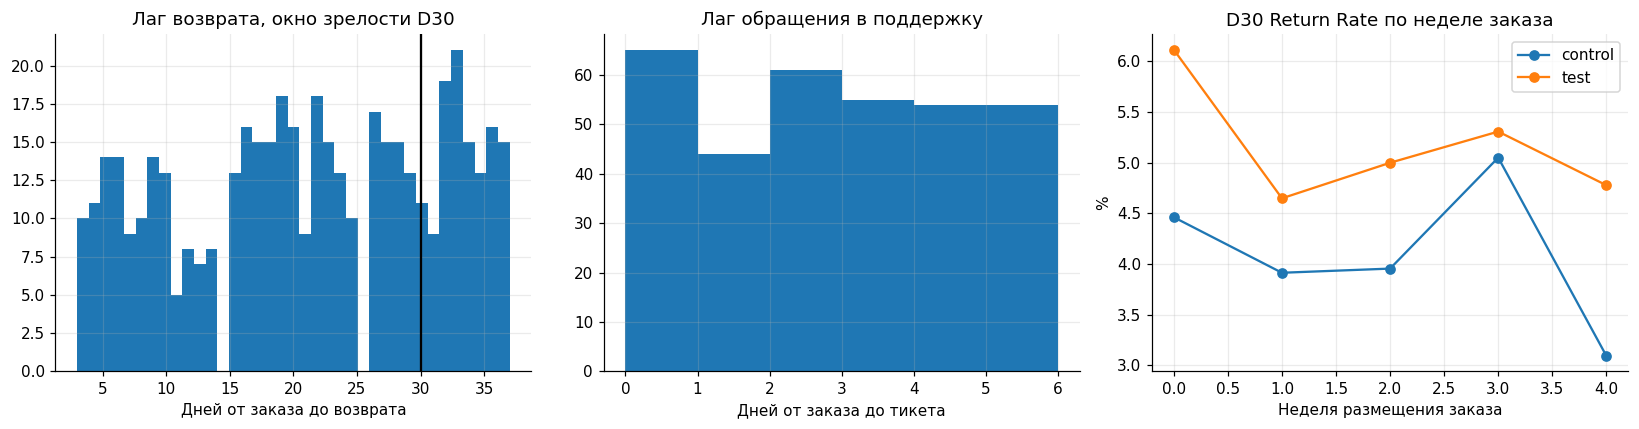

In [4]:
for w in [7, 14, P['returns_maturity_days']]:
    o[f'ret_d{w}'] = ((o.is_returned == 1) & (o.return_lag_days <= w)).astype(int)
o['ret_all'] = o.is_returned.astype(int)
o['ret_naive_window'] = ((o.is_returned == 1) & (o.return_date <= EXP_END)).astype(int)

ord_grp = o.merge(cohort, on='user_id')

rows = []
for col, label in [('ret_naive_window', 'Обрезка по окну эксперимента (неверно)'),
                   ('ret_d7',  'D7 maturity'),
                   ('ret_d14', 'D14 maturity'),
                   (f'ret_d{P["returns_maturity_days"]}', 'D30 maturity (база решения)'),
                   ('ret_all', 'Полная история (conservative)')]:
    g = ord_grp.groupby('experiment_group')[col].agg(['sum', 'size'])
    rc = g.loc['control', 'sum'] / g.loc['control', 'size']
    rt = g.loc['test', 'sum'] / g.loc['test', 'size']
    rows.append({'Определение возврата': label, 'Возвратов': int(ord_grp[col].sum()),
                 'RR control, %': rc * 100, 'RR test, %': rt * 100,
                 'Разница, п.п.': (rt - rc) * 100, 'Относительный рост, %': (rt / rc - 1) * 100})

returns_maturity = pd.DataFrame(rows).round(3)
display(returns_maturity)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(o.return_lag_days.dropna(), bins=37)
axes[0].axvline(P['returns_maturity_days'], color='black', linewidth=1.5)
axes[0].set_title('Лаг возврата, окно зрелости D30')
axes[0].set_xlabel('Дней от заказа до возврата')

axes[1].hist(tk.ticket_lag_days, bins=range(0, TICKET_MAX_LAG + 2))
axes[1].set_title('Лаг обращения в поддержку')
axes[1].set_xlabel('Дней от заказа до тикета')

wk = ord_grp.assign(week=(ord_grp.order_date - EXP_START).dt.days // 7)
piv = wk.pivot_table(index='week', columns='experiment_group',
                     values=f'ret_d{P["returns_maturity_days"]}', aggfunc='mean') * 100
axes[2].plot(piv.index, piv.control, marker='o', label='control')
axes[2].plot(piv.index, piv.test, marker='o', label='test')
axes[2].set_title('D30 Return Rate по неделе заказа')
axes[2].set_xlabel('Неделя размещения заказа')
axes[2].set_ylabel('%')
axes[2].legend()

plt.tight_layout()
plt.show()

Проверка показывает, что возвраты и обращения в поддержку достаточно зрелые для основной оценки.

**Возвраты.** Медианный лаг возврата составляет 22 дня, максимальный наблюдаемый лаг 37 дней. Даже для самого позднего заказа доступно не менее 36 дней наблюдения. Поэтому исход D30 полностью наблюдаем для всех заказов и дополнительная поправка на цензурирование не нужна.

**Обращения в поддержку.** Максимальный лаг обращения от даты заказа составляет 5 дней, медианный 2 дня. Возможный недобор затрагивает только небольшую часть самых поздних заказов и практически не влияет на оценку прироста.

Определение окна заметно меняет уровень возвратов:

| Правило | Контроль | Тест | Относительный рост |
|---|---:|---:|---:|
| Обрезка по окну эксперимента | 2.00 % | 2.36 % | +17.7 % |
| D7 | 0.74 % | 0.83 % | +12.1 % |
| D14 | 1.55 % | 1.78 % | +15.1 % |
| **D30, основной сценарий** | **4.26 %** | **5.23 %** | **+22.8 %** |
| Вся доступная история | 5.55 % | 6.85 % | +23.4 % |

Обрезка по календарному окну эксперимента занизила бы и уровень возвратов, и риск новой модели. Поэтому основной сценарий строим на D30.

D7 и D14 используем только как ранние окна мониторинга. Они содержат еще не все будущие возвраты и не заменяют зрелую оценку D30.

В качестве консервативной проверки чувствительности (conservative sensitivity) отдельно считаем все наблюдаемые возвраты, включая возвраты после D30.

### 1.3 Пользовательская витрина и определения метрик

Все компоненты модели приводим к одной единице анализа, **подходящему активному пользователю (eligible active user)**.

Это нужно по двум причинам:

1. Эксперимент рандомизирован по `user_id`.
2. Бизнес-ограничения первой волны тоже заданы на уровне пользователей, которым показывается новая модель.

В таблице `user_mart` одна строка соответствует одному пользователю основной когорты.

Признаки делим на две группы.

**Исходные признаки**, известные до воздействия модели и допустимые для правила запуска: `device`, Premium-статус на старте, срок жизни пользователя (`tenure`), `region`, `traffic_source`, `age_group`.

**Метрики результата**, появившиеся после воздействия: число заказов, GMV, валовая маржа, возвраты D7/D14/D30 и обращения в поддержку.

Если у пользователя не было заказа, возврата или обращения, соответствующая метрика равна нулю. Это наблюдаемое отсутствие события, а не пропуск.

In [5]:
ord_decision = orders_c.copy()
ord_decision['return_lag_days'] = (
    ord_decision.return_date - ord_decision.order_date
).dt.days

for w in [7, 14, P['returns_maturity_days']]:
    ord_decision[f'returns_d{w}'] = (
        (ord_decision.is_returned == 1) &
        (ord_decision.return_lag_days <= w)
    ).astype(int)

ord_decision['returns_all'] = ord_decision.is_returned.astype(int)

ord_user = ord_decision.groupby('user_id').agg(
    orders=('order_id', 'size'),
    gmv_rub=('gmv_rub', 'sum'),
    gross_margin_rub=('gross_margin_rub', 'sum'),
    returns_d7=('returns_d7', 'sum'),
    returns_d14=('returns_d14', 'sum'),
    returns_d30=('returns_d30', 'sum'),
    returns_all=('returns_all', 'sum'),
)

ticket_user = tickets_c.groupby('user_id').agg(
    support_tickets=('ticket_id', 'size')
)

baseline = users_c[
    ['user_id', 'registration_date', 'device', 'region',
     'age_group', 'traffic_source', 'is_premium']
].copy()

user_mart = (
    cohort
    .merge(
        baseline,
        on='user_id',
        how='left',
        validate='one_to_one'
    )
    .join(ord_user, on='user_id')
    .join(ticket_user, on='user_id')
)

count_cols = [
    'orders', 'returns_d7', 'returns_d14',
    'returns_d30', 'returns_all', 'support_tickets'
]

money_cols = ['gmv_rub', 'gross_margin_rub']

user_mart[count_cols] = (
    user_mart[count_cols]
    .fillna(0)
    .astype(int)
)

user_mart[money_cols] = (
    user_mart[money_cols]
    .fillna(0.0)
)

user_mart['tenure_days'] = (
    EXP_START - user_mart.registration_date
).dt.days

TENURE_BINS = [-1, 30, 90, 180, 365, 10**5]
TENURE_LABELS = [
    'до 1 мес',
    '1-3 мес',
    '3-6 мес',
    '6-12 мес',
    'более года'
]

user_mart['tenure_bucket'] = pd.cut(
    user_mart.tenure_days,
    bins=TENURE_BINS,
    labels=TENURE_LABELS
)

policy_features = [
    'device',
    'is_premium',
    'tenure_days',
    'tenure_bucket',
    'region',
    'traffic_source',
    'age_group'
]

outcome_cols = [
    'orders',
    'gmv_rub',
    'gross_margin_rub',
    'returns_d7',
    'returns_d14',
    'returns_d30',
    'returns_all',
    'support_tickets'
]

assert len(user_mart) == N_ELIGIBLE
assert user_mart.user_id.nunique() == len(user_mart)
assert user_mart[policy_features].isna().sum().sum() == 0

mart_check = pd.DataFrame({
    'Проверка': [
        'Строк в user_mart',
        'Уникальных user_id',
        'Заказов',
        'D30 возвратов',
        'Всех зарегистрированных возвратов',
        'Тикетов поддержки',
    ],
    'Значение': [
        len(user_mart),
        user_mart.user_id.nunique(),
        user_mart.orders.sum(),
        user_mart.returns_d30.sum(),
        user_mart.returns_all.sum(),
        user_mart.support_tickets.sum(),
    ]
})

display(mart_check)
display(user_mart.head())

,Проверка,Значение
0,Строк в user_mart,49301
1,Уникальных user_id,49301
2,Заказов,7302
3,D30 возвратов,352
4,Всех зарегистрированных возвратов,460
5,Тикетов поддержки,333


,user_id,experiment_group,registration_date,device,region,age_group,traffic_source,is_premium,orders,gmv_rub,gross_margin_rub,returns_d7,returns_d14,returns_d30,returns_all,support_tickets,tenure_days,tenure_bucket
0,u_000001,control,2026-04-29,android,Volga,18-24,paid_ads,0,0,0.0000,0.0000,0,0,0,0,0,63,1-3 мес
1,u_000002,test,2026-02-25,android,Central Russia,35-44,direct,0,0,0.0000,0.0000,0,0,0,0,0,126,3-6 мес
2,u_000003,control,2026-04-01,web,Moscow,18-24,push,1,0,0.0000,0.0000,0,0,0,0,0,91,3-6 мес
3,u_000004,control,2026-03-08,ios,Ural,25-34,paid_ads,0,0,0.0000,0.0000,0,0,0,0,0,115,3-6 мес
4,u_000005,test,2025-07-28,android,Central Russia,18-24,organic,1,0,0.0000,0.0000,0,0,0,0,0,338,6-12 мес


Витрина прошла сверку с исходными таблицами. В ней **49 301 строка и 49 301 уникальный `user_id`**, поэтому единица анализа действительно соответствует пользователю.

Суммы также совпадают с очищенными исходными данными. Получаем 7 302 заказа, 352 возврата D30 и 333 обращения в поддержку.

В основной модели используется `returns_d30`. Переменная `returns_all` хранится отдельно и применяется только в консервативном сценарии чувствительности.

Эффект по каждой метрике оцениваем как разность средних между тестовой и контрольной группами. Благодаря этому финансовые показатели и ограничения риска имеют единый пользовательский знаменатель.

#### `metric_definition`: определения метрик

До оценки эффекта фиксируем формулы, единицы измерения и знаменатели всех метрик.

Через $\Delta$ обозначаем разность между тестовой и контрольной группами.

Ограничения по риску считаются не на заказ, а на пользователя, которому показана новая модель. Поэтому доля возвратов D30 используется как диагностическая метрика, а основное ограничение считается как число дополнительных возвратов на 100 000 пользователей под воздействием модели.

In [6]:
metric_definition = pd.DataFrame([
    {
        'metric': 'GMV per user',
        'role': 'topline diagnostic',
        'formula': 'Σ gmv_rub / N users',
        'numerator': 'Σ gmv_rub',
        'denominator': 'eligible active users',
        'unit': '₽ / user / 30d',
        'window': 'orders placed in 1-30 Jul',
        'decision_use': 'reconciliation only; not a direct net contribution component',
    },
    {
        'metric': 'Gross margin per user',
        'role': 'value component',
        'formula': 'Σ gross_margin_rub / N users',
        'numerator': 'Σ gross_margin_rub',
        'denominator': 'eligible active users',
        'unit': '₽ / user / 30d',
        'window': 'orders placed in 1-30 Jul',
        'decision_use': 'Δ(test-control) is the value part of net contribution',
    },
    {
        'metric': 'D30 Return Rate',
        'role': 'maturity diagnostic',
        'formula': 'Σ returns_d30 / Σ orders',
        'numerator': 'D30 returned orders',
        'denominator': 'orders',
        'unit': '% orders',
        'window': 'return within 30 days after order',
        'decision_use': 'diagnostic only; guardrail denominator is exposed users',
    },
    {
        'metric': 'Incremental returns',
        'role': 'risk guardrail',
        'formula': '(mean_T[returns_d30] - mean_C[returns_d30]) × 100000',
        'numerator': 'incremental D30 returns',
        'denominator': 'exposed users',
        'unit': 'additional returns / 100k exposed / 30d',
        'window': 'D30 maturity',
        'decision_use': '95% upper bound must be <= 650',
    },
    {
        'metric': 'Incremental support tickets',
        'role': 'risk guardrail',
        'formula': '(mean_T[tickets] - mean_C[tickets]) × 100000',
        'numerator': 'incremental support tickets',
        'denominator': 'exposed users',
        'unit': 'additional tickets / 100k exposed / 30d',
        'window': 'observed ticket lag; effectively mature',
        'decision_use': '95% upper bound must be <= 300',
    },
    {
        'metric': 'Net contribution / exposed user',
        'role': 'primary decision metric',
        'formula': (
            'Δmargin - 700×Δreturns - 350×Δtickets - 1.20 '
            '- 350×max(0, Δtickets - 250/100000)'
        ),
        'numerator': 'incremental margin minus incremental costs',
        'denominator': 'exposed users',
        'unit': '₽ / exposed user / 30d',
        'window': '30d experiment effect',
        'decision_use': '95% lower bound must be > 0',
    },
    {
        'metric': 'Net contribution / exposed user, 8 weeks',
        'role': 'planning metric',
        'formula': 'Net contribution 30d × 56/30',
        'numerator': 'scaled 30d net contribution',
        'denominator': 'exposed users',
        'unit': '₽ / exposed user / 56d',
        'window': '8-week planning horizon',
        'decision_use': 'financial result of rollout policy',
    },
])

display(metric_definition)

,metric,role,formula,numerator,denominator,unit,window,decision_use
0,GMV per user,topline diagnostic,Σ gmv_rub / N users,Σ gmv_rub,eligible active users,₽ / user / 30d,orders placed in 1-30 Jul,reconciliation only; not a direct net contribu...
1,Gross margin per user,value component,Σ gross_margin_rub / N users,Σ gross_margin_rub,eligible active users,₽ / user / 30d,orders placed in 1-30 Jul,Δ(test-control) is the value part of net contr...
2,D30 Return Rate,maturity diagnostic,Σ returns_d30 / Σ orders,D30 returned orders,orders,% orders,return within 30 days after order,diagnostic only; guardrail denominator is expo...
3,Incremental returns,risk guardrail,(mean_T[returns_d30] - mean_C[returns_d30]) × ...,incremental D30 returns,exposed users,additional returns / 100k exposed / 30d,D30 maturity,95% upper bound must be <= 650
4,Incremental support tickets,risk guardrail,(mean_T[tickets] - mean_C[tickets]) × 100000,incremental support tickets,exposed users,additional tickets / 100k exposed / 30d,observed ticket lag; effectively mature,95% upper bound must be <= 300
5,Net contribution / exposed user,primary decision metric,Δmargin - 700×Δreturns - 350×Δtickets - 1.20 -...,incremental margin minus incremental costs,exposed users,₽ / exposed user / 30d,30d experiment effect,95% lower bound must be > 0
6,"Net contribution / exposed user, 8 weeks",planning metric,Net contribution 30d × 56/30,scaled 30d net contribution,exposed users,₽ / exposed user / 56d,8-week planning horizon,financial result of rollout policy


### 1.4 Чистый вклад (Net Contribution)

Основная финансовая метрика, **дополнительный чистый вклад на одного пользователя под воздействием модели**.

Обозначения:

- $\Delta M$ , дополнительная валовая маржа на пользователя
- $\Delta R$ , дополнительные возвраты D30 на пользователя
- $\Delta T$ , дополнительные обращения в поддержку на пользователя
- $c_R=700$ ₽ , стоимость обработки дополнительного возврата
- $c_T=350$ ₽ , стоимость дополнительного обращения
- $c_I=1.20$ ₽ , стоимость инференса модели на пользователя за 30 дней
- $K=250/100000$ , бесплатная емкость поддержки в расчете на одного пользователя

Тогда:

$$
NC_{30}
=
\Delta M
-700\Delta R
-350\Delta T
-1.20
-350\max\left(0,\Delta T-
rac{250}{100000}\right)
$$

Первые 350 ₽ вычитаются для каждого дополнительного обращения. Если прирост обращений превышает доступную емкость поддержки, каждое обращение сверх лимита добавляет еще 350 ₽ расходов.

Для планового горизонта 8 недель:

$$
NC_{56}=NC_{30}\times\frac{56}{30}.
$$

Коэффициент $56/30$ переводит 30-дневный эффект в 56-дневный горизонт при допущении, что средний эффект остается постоянным. Это плановая экстраполяция, а не отдельная причинная оценка на 56 дней.

In [7]:
def point_effects(df, return_col='returns_d30'):
    g = (
        df.groupby('experiment_group')
        .agg(
            users=('user_id', 'size'),
            gross_margin_rub=('gross_margin_rub', 'sum'),
            returns=(return_col, 'sum'),
            support_tickets=('support_tickets', 'sum')
        )
    )

    g['margin_per_user'] = g.gross_margin_rub / g.users
    g['returns_per_user'] = g.returns / g.users
    g['tickets_per_user'] = g.support_tickets / g.users

    return pd.Series({
        'delta_margin_per_user':
            g.loc['test', 'margin_per_user']
            - g.loc['control', 'margin_per_user'],

        'delta_returns_per_user':
            g.loc['test', 'returns_per_user']
            - g.loc['control', 'returns_per_user'],

        'delta_tickets_per_user':
            g.loc['test', 'tickets_per_user']
            - g.loc['control', 'tickets_per_user'],
    })


def calc_net_contribution(effects, params=P):
    dm = effects['delta_margin_per_user']
    dr = effects['delta_returns_per_user']
    dt = effects['delta_tickets_per_user']

    free_support_per_user = (
        params['support_free_tickets_per_100k'] / 100_000
    )

    excess_tickets_per_user = max(
        0.0,
        dt - free_support_per_user
    )

    return_cost = (
        params['return_handling_rub'] * dr
    )

    support_cost = (
        params['support_ticket_rub'] * dt
    )

    inference_cost = (
        params['ai_inference_rub_per_exposed_30d']
    )

    excess_capacity_cost = (
        params['support_ticket_rub']
        * excess_tickets_per_user
    )

    net_30d = (
        dm
        - return_cost
        - support_cost
        - inference_cost
        - excess_capacity_cost
    )

    return pd.Series({
        'incremental_gross_margin_rub': dm,
        'return_handling_cost_rub': return_cost,
        'support_cost_rub': support_cost,
        'inference_cost_rub': inference_cost,
        'excess_capacity_cost_rub': excess_capacity_cost,

        'net_contribution_30d_rub': net_30d,
        'net_contribution_56d_rub':
            net_30d * params['scale_to_horizon'],

        'returns_uplift_per_100k':
            dr * 100_000,

        'tickets_uplift_per_100k':
            dt * 100_000,

        'excess_tickets_per_100k':
            excess_tickets_per_user * 100_000,
    })


base_effects = point_effects(
    user_mart,
    return_col='returns_d30'
)

base_net = calc_net_contribution(
    base_effects
)

display(base_net.round(4))

incremental_gross_margin_rub    11.1752
return_handling_cost_rub         2.4271
support_cost_rub                 0.9457
inference_cost_rub               1.2000
excess_capacity_cost_rub         0.0707
net_contribution_30d_rub         6.5317
net_contribution_56d_rub        12.1925
returns_uplift_per_100k        346.7264
tickets_uplift_per_100k        270.1999
excess_tickets_per_100k         20.1999
dtype: float64

Финансовый расчет вынесен в функцию. Если изменить бизнес-параметры в `P` и заново выполнить ноутбук, связанные расчеты пересчитаются автоматически.

#### Проверка двойного учета расходов

Важно не вычесть потери от возврата дважды.

Поле `gross_margin_rub` уже отражает экономический результат заказа. Для зарегистрированных возвратов валовая маржа отрицательная. Поэтому саму потерю маржи повторно из чистого вклада не вычитаем.

Отдельно учитываем только заданную в условии операционную стоимость обработки возврата 700 ₽.

Расходы на поддержку и инференс модели в валовую маржу не входят, поэтому они учитываются отдельно.

GMV не прибавляется к валовой марже и используется только как сводная диагностическая метрика.

In [8]:
returned_negative = (
    (orders_c.is_returned == 1) &
    (orders_c.gross_margin_rub < 0)
).sum()

nonreturned_negative = (
    (orders_c.is_returned == 0) &
    (orders_c.gross_margin_rub < 0)
).sum()

margin_return_check = pd.DataFrame({
    'Проверка': [
        'Возвращённых заказов после очистки',
        'Из них с отрицательной gross_margin_rub',
        'Невернувшихся заказов с отрицательной gross_margin_rub',
    ],
    'Значение': [
        int(orders_c.is_returned.sum()),
        int(returned_negative),
        int(nonreturned_negative),
    ]
})

double_counting_check = pd.DataFrame([
    (
        'Экономический эффект возврата внутри заказа',
        'Да',
        'НЕ вычитать повторно',
        'У возвращённых заказов gross_margin_rub уже отрицательная'
    ),
    (
        'Обработка дополнительного возврата',
        'Нет',
        '-700 ₽ × Δ D30 returns',
        'Отдельная операционная стоимость из условия'
    ),
    (
        'Дополнительный ticket поддержки',
        'Нет',
        '-350 ₽ × Δ tickets',
        'Отдельная стоимость из условия'
    ),
    (
        'Excess support capacity',
        'Нет',
        'Ещё -350 ₽ за ticket сверх 250/100k',
        'Дополнительная стоимость сверх обычного support cost'
    ),
    (
        'AI inference',
        'Нет',
        '-1.20 ₽ / exposed user / 30d',
        'Отдельная стоимость из условия'
    ),
    (
        'GMV',
        'Не cost-компонента',
        'Не добавлять в net contribution',
        'Используется только для topline reconciliation'
    ),
], columns=[
    'Компонента',
    'Уже в gross_margin_rub',
    'Действие в net contribution',
    'Обоснование'
])

display(margin_return_check)
display(double_counting_check)

,Проверка,Значение
0,Возвращённых заказов после очистки,460
1,Из них с отрицательной gross_margin_rub,460
2,Невернувшихся заказов с отрицательной gross_ma...,0


,Компонента,Уже в gross_margin_rub,Действие в net contribution,Обоснование
0,Экономический эффект возврата внутри заказа,Да,НЕ вычитать повторно,У возвращённых заказов gross_margin_rub уже от...
1,Обработка дополнительного возврата,Нет,-700 ₽ × Δ D30 returns,Отдельная операционная стоимость из условия
2,Дополнительный ticket поддержки,Нет,-350 ₽ × Δ tickets,Отдельная стоимость из условия
3,Excess support capacity,Нет,Ещё -350 ₽ за ticket сверх 250/100k,Дополнительная стоимость сверх обычного suppor...
4,AI inference,Нет,-1.20 ₽ / exposed user / 30d,Отдельная стоимость из условия
5,GMV,Не cost-компонента,Не добавлять в net contribution,Используется только для topline reconciliation


По точечной оценке новая модель дает **+11.18 ₽ дополнительной валовой маржи** на одного пользователя за 30 дней.

После учета операционных расходов эффект уменьшается. На обработку дополнительных возвратов приходится 2.43 ₽, на поддержку 0.95 ₽, на инференс модели 1.20 ₽ и еще 0.07 ₽ на превышение базовой емкости поддержки.

Итоговая точечная оценка составляет **+6.53 ₽ чистого вклада на пользователя за 30 дней**. На горизонте 8 недель это соответствует +12.19 ₽ при линейном масштабировании $56/30$.

Точечный прирост рисков равен 346.7 дополнительного возврата D30 и 270.2 дополнительного обращения в поддержку на 100 000 пользователей.

Обе точечные оценки ниже заданных лимитов. Однако по условию кейса ограничения риска проверяются по верхней границе 95 % доверительного интервала, а положительный финансовый эффект по нижней границе 95 % доверительного интервала.

Поэтому далее оцениваем совместную неопределенность всех компонентов на уровне пользователя.

### 1.5 Совместный бутстрэп на уровне пользователя

Точечной оценки недостаточно для решения о запуске. По условию должны выполняться три требования:

1. Нижняя граница 95 % доверительного интервала чистого вклада выше нуля.
2. Верхняя граница 95 % доверительного интервала дополнительных возвратов не выше 650 на 100 000 пользователей.
3. Верхняя граница 95 % доверительного интервала дополнительных обращений в поддержку не выше 300 на 100 000 пользователей.

Неопределенность оцениваем бутстрэпом (bootstrap) на уровне `user_id`, потому что пользователь является единицей рандомизации.

На каждой итерации отдельно пересэмплируем с возвращением пользователей тестовой и контрольной групп, сохраняя исходный размер групп. Для валовой маржи, возвратов и обращений используется один и тот же набор пересэмплированных пользователей. Так сохраняется зависимость между метриками одного пользователя.

Из каждой итерации сразу рассчитываем чистый вклад, включая дополнительный расход при превышении емкости поддержки.

Используем 6 000 итераций и фиксированный `seed` из `P`, поэтому при неизменных данных и параметрах результат воспроизводится.

In [9]:
def joint_user_bootstrap(
    df,
    n_boot=P['n_boot'],
    seed=P['seed'],
    batch_size=50
):
    cols = [
        'gross_margin_rub',
        'returns_d14',
        'returns_d30',
        'returns_all',
        'support_tickets'
    ]

    test = (
        df.loc[df.experiment_group == 'test', cols]
        .to_numpy(dtype=np.float64)
    )

    control = (
        df.loc[df.experiment_group == 'control', cols]
        .to_numpy(dtype=np.float64)
    )

    rng = np.random.default_rng(seed)

    out = np.empty((n_boot, len(cols)))

    for start in range(0, n_boot, batch_size):
        end = min(start + batch_size, n_boot)
        b = end - start

        idx_t = rng.integers(
            0, len(test),
            size=(b, len(test)),
            dtype=np.int32
        )

        idx_c = rng.integers(
            0, len(control),
            size=(b, len(control)),
            dtype=np.int32
        )

        for j in range(len(cols)):
            mean_t = test[idx_t, j].mean(axis=1)
            mean_c = control[idx_c, j].mean(axis=1)

            out[start:end, j] = mean_t - mean_c

    return pd.DataFrame(
        out,
        columns=[
            'delta_margin_per_user',
            'delta_returns_d14_per_user',
            'delta_returns_d30_per_user',
            'delta_returns_all_per_user',
            'delta_tickets_per_user'
        ]
    )


boot = joint_user_bootstrap(user_mart)

print(f'Bootstrap draws: {len(boot):,}')
display(boot.head())

Bootstrap draws: 6,000


,delta_margin_per_user,delta_returns_d14_per_user,delta_returns_d30_per_user,delta_returns_all_per_user,delta_tickets_per_user
0,9.9463,0.0015,0.0038,0.0050,0.0016
1,11.8644,0.0004,0.0017,0.0040,0.0030
2,9.2269,0.0022,0.0057,0.0069,0.0038
3,9.8391,0.0003,0.0022,0.0030,0.0025
4,9.5310,0.0014,0.0036,0.0056,0.0019


На каждой итерации бутстрэпа одновременно получаем четыре связанные величины: дополнительную валовую маржу, два определения возвратов и дополнительные обращения в поддержку.

Это позволяет рассчитывать доверительный интервал чистого вклада напрямую, без независимого объединения интервалов отдельных метрик.

Такой подход учитывает, что один пользователь может одновременно принести дополнительную маржу, оформить возврат и обратиться в поддержку. Он также учитывает нелинейный дополнительный расход после превышения емкости поддержки.

Далее для каждой итерации бутстрэпа пересчитываем финансовый результат и проверяем ограничения риска.

In [10]:
def bootstrap_economics(
    boot_df,
    return_col,
    params=P
):
    dm = boot_df['delta_margin_per_user'].to_numpy()
    dr = boot_df[return_col].to_numpy()
    dt = boot_df['delta_tickets_per_user'].to_numpy()

    free_support_per_user = (
        params['support_free_tickets_per_100k']
        / 100_000
    )

    excess = np.maximum(
        0.0,
        dt - free_support_per_user
    )

    net_30d = (
        dm
        - params['return_handling_rub'] * dr
        - params['support_ticket_rub'] * dt
        - params['ai_inference_rub_per_exposed_30d']
        - params['support_ticket_rub'] * excess
    )

    return pd.DataFrame({
        'net_contribution_30d_rub': net_30d,

        'net_contribution_56d_rub':
            net_30d * params['scale_to_horizon'],

        'returns_uplift_per_100k':
            dr * 100_000,

        'tickets_uplift_per_100k':
            dt * 100_000
    })

#### Основной, консервативный и оптимистичный сценарии

Условие требует показать основной, консервативный и оптимистичный сценарии. Дополнительных значений стоимости возврата, поддержки или инференса в кейсе нет, поэтому бизнес-параметры не меняем. Сценарии различаются только определением возврата.

**Основной сценарий, D30.** Используем `returns_d30`. Для каждого заказа действует одинаковое 30-дневное окно зрелости.

**Консервативный сценарий.** Используем `returns_all`, то есть учитываем все наблюдаемые возвраты, включая возвраты после D30. Это увеличивает оценку риска и используется только как проверка чувствительности.

**Оптимистичный сценарий, D14.** Учитываем возвраты в первые 14 дней. Этот вариант используется только как дополнительная проверка чувствительности и не заменяет основной показатель D30.

Остальные параметры экономики во всех трех сценариях одинаковы.

Ниже приведена итоговая таблица по трем сценариям.

In [11]:
scenario_defs = {
    'Base': {
        'return_col_point': 'returns_d30',
        'return_col_boot': 'delta_returns_d30_per_user',
        'return_definition': 'D30 maturity'
    },

    'Conservative': {
        'return_col_point': 'returns_all',
        'return_col_boot': 'delta_returns_all_per_user',
        'return_definition': 'All observed returns'
    },

    'Upside': {
        'return_col_point': 'returns_d14',
        'return_col_boot': 'delta_returns_d14_per_user',
        'return_definition': 'D14 sensitivity'
    }
}


rows = []

for scenario, cfg in scenario_defs.items():

    point = calc_net_contribution(
        point_effects(
            user_mart,
            return_col=cfg['return_col_point']
        )
    )

    boot_s = bootstrap_economics(
        boot,
        return_col=cfg['return_col_boot']
    )

    nc_l, nc_u = boot_s[
        'net_contribution_30d_rub'
    ].quantile([0.025, 0.975])

    nc56_l, nc56_u = boot_s[
        'net_contribution_56d_rub'
    ].quantile([0.025, 0.975])

    ret_l, ret_u = boot_s[
        'returns_uplift_per_100k'
    ].quantile([0.025, 0.975])

    sup_l, sup_u = boot_s[
        'tickets_uplift_per_100k'
    ].quantile([0.025, 0.975])

    nc_ok = nc_l > 0

    returns_ok = (
        ret_u
        <= P['guardrail_returns_per_100k']
    )

    support_ok = (
        sup_u
        <= P['guardrail_tickets_per_100k']
    )

    failed = []

    if not nc_ok:
        failed.append('NC')

    if not returns_ok:
        failed.append('returns')

    if not support_ok:
        failed.append('support')

    decision = (
        'PASS'
        if len(failed) == 0
        else 'FAIL: ' + ', '.join(failed)
    )

    rows.append({
        'scenario': scenario,
        'return_definition': cfg['return_definition'],

        'nc_30d_point': point[
            'net_contribution_30d_rub'
        ],
        'nc_30d_l95': nc_l,
        'nc_30d_u95': nc_u,

        'nc_56d_point': point[
            'net_contribution_56d_rub'
        ],
        'nc_56d_l95': nc56_l,
        'nc_56d_u95': nc56_u,

        'returns_point_per_100k': point[
            'returns_uplift_per_100k'
        ],
        'returns_l95': ret_l,
        'returns_u95': ret_u,

        'support_point_per_100k': point[
            'tickets_uplift_per_100k'
        ],
        'support_l95': sup_l,
        'support_u95': sup_u,

        'nc_ok': nc_ok,
        'returns_ok': returns_ok,
        'support_ok': support_ok,

        'decision': decision
    })


scenario_results = pd.DataFrame(rows)

display(
    scenario_results.round(2)
)

,scenario,return_definition,nc_30d_point,nc_30d_l95,nc_30d_u95,nc_56d_point,nc_56d_l95,nc_56d_u95,returns_point_per_100k,returns_l95,returns_u95,support_point_per_100k,support_l95,support_u95,nc_ok,returns_ok,support_ok,decision
0,Base,D30 maturity,6.5300,3.5500,9.3100,12.1900,6.6200,17.3900,346.7300,196.5300,495.1200,270.2000,124.0900,415.7800,True,True,False,FAIL: support
1,Conservative,All observed returns,5.7600,2.6800,8.6400,10.7500,5.0000,16.1300,457.1700,283.8500,627.2100,270.2000,124.0900,415.7800,True,True,False,FAIL: support
2,Upside,D14 sensitivity,8.2200,5.4600,10.8300,15.3400,10.1900,20.2200,105.9400,16.9800,194.9600,270.2000,124.0900,415.7800,True,True,False,FAIL: support


In [12]:
scenario_view = scenario_results[
    [
        'scenario',
        'return_definition',
        'nc_30d_point',
        'nc_30d_l95',
        'nc_30d_u95',
        'returns_point_per_100k',
        'returns_u95',
        'support_point_per_100k',
        'support_u95',
        'decision'
    ]
].copy()

scenario_view.columns = [
    'Scenario',
    'Returns',
    'NC point, ₽',
    'NC L95',
    'NC U95',
    'Returns point / 100k',
    'Returns U95',
    'Support point / 100k',
    'Support U95',
    'Decision'
]

display(
    scenario_view.round(2)
)

,Scenario,Returns,"NC point, ₽",NC L95,NC U95,Returns point / 100k,Returns U95,Support point / 100k,Support U95,Decision
0,Base,D30 maturity,6.5300,3.5500,9.3100,346.7300,495.1200,270.2000,415.7800,FAIL: support
1,Conservative,All observed returns,5.7600,2.6800,8.6400,457.1700,627.2100,270.2000,415.7800,FAIL: support
2,Upside,D14 sensitivity,8.2200,5.4600,10.8300,105.9400,194.9600,270.2000,415.7800,FAIL: support


### Вывод по совокупному эффекту

Совместный бутстрэп показывает, что финансовый эффект новой модели положительный, но запуск на всю активную аудиторию не проходит ограничение по поддержке.

В основном сценарии чистый вклад составляет **+6.53 ₽ на пользователя за 30 дней**, 95 % доверительный интервал равен **[3.55, 9.31] ₽**. Нижняя граница выше нуля.

На горизонте 8 недель плановая оценка составляет **+12.19 ₽ на пользователя**, 95 % доверительный интервал **[6.62, 17.39] ₽**.

Для возвратов D30 точечная оценка равна **346.7 на 100 000 пользователей**, верхняя граница 95 % доверительного интервала равна **495.1** при лимите 650.

В консервативном сценарии учитываются все наблюдаемые возвраты. Верхняя граница увеличивается до **627.2 на 100 000**, но остается ниже лимита 650. Значит вывод по возвратам не меняется.

Главное ограничение связано с поддержкой. Точечная оценка равна **270.2 обращения на 100 000**, что ниже лимита 300. При этом верхняя граница 95 % доверительного интервала равна **415.8**, поэтому совокупная аудитория не проходит обязательное ограничение.

Это ограничение не зависит от выбранного окна возвратов. Во всех трех сценариях совокупный запуск получает отказ из-за риска для поддержки.

Следовательно, от новой модели не отказываемся, но запуск на всю подходящую активную аудиторию без отбора пользователей не подходит. Далее ищем более безопасную аудиторию по признакам, известным до воздействия модели.

### 1.6 Сверка со сводными метриками и фиксация допущений

Перед выбором правила запуска выполняем две проверки.

Сначала сверяем пользовательскую витрину с очищенными исходными таблицами. Это подтверждает, что при переходе на уровень `user_id` не потерялись и не задублировались заказы, GMV, валовая маржа, возвраты и обращения в поддержку.

Затем сопоставляем основную финансовую метрику со сводными показателями эксперимента. Это нужно, чтобы понимать, за счет каких изменений поведения возникает финансовый эффект.

GMV в финансовую формулу повторно не добавляется. Финансовым компонентом остается дополнительная валовая маржа.

Сначала проверяем совпадение пользовательской витрины с очищенными исходными таблицами.

In [13]:
reconciliation_check = pd.DataFrame([
    {
        'metric': 'Orders',
        'source_value': len(orders_c),
        'user_mart_value': user_mart.orders.sum()
    },
    {
        'metric': 'GMV, ₽',
        'source_value': orders_c.gmv_rub.sum(),
        'user_mart_value': user_mart.gmv_rub.sum()
    },
    {
        'metric': 'Gross margin, ₽',
        'source_value': orders_c.gross_margin_rub.sum(),
        'user_mart_value': user_mart.gross_margin_rub.sum()
    },
    {
        'metric': 'D30 returns',
        'source_value': ord_decision.returns_d30.sum(),
        'user_mart_value': user_mart.returns_d30.sum()
    },
    {
        'metric': 'All observed returns',
        'source_value': orders_c.is_returned.sum(),
        'user_mart_value': user_mart.returns_all.sum()
    },
    {
        'metric': 'Support tickets',
        'source_value': len(tickets_c),
        'user_mart_value': user_mart.support_tickets.sum()
    },
])

reconciliation_check['match'] = np.isclose(
    reconciliation_check['source_value'],
    reconciliation_check['user_mart_value']
)

display(reconciliation_check)

,metric,source_value,user_mart_value,match
0,Orders,"7,302.0000","7,302.0000",True
1,"GMV, ₽","12,224,862.0000","12,224,862.0000",True
2,"Gross margin, ₽","2,001,081.5500","2,001,081.5500",True
3,D30 returns,352.0000,352.0000,True
4,All observed returns,460.0000,460.0000,True
5,Support tickets,333.0000,333.0000,True


Все ключевые суммы совпадают между очищенными исходными таблицами и `user_mart`.

Получаем 7 302 заказа, 12.22 млн ₽ GMV, 2.00 млн ₽ валовой маржи, 352 возврата D30, 460 возвратов за всю доступную историю и 333 обращения в поддержку.

Следовательно, переход на пользовательский уровень не изменил наблюдаемые результаты.

Теперь сравниваем финансовый результат со сводными показателями эксперимента.

In [14]:
topline = (
    user_mart
    .groupby('experiment_group')
    .agg(
        users=('user_id', 'size'),
        orders=('orders', 'sum'),
        gmv_rub=('gmv_rub', 'sum'),
        gross_margin_rub=('gross_margin_rub', 'sum'),
        returns_d30=('returns_d30', 'sum'),
        support_tickets=('support_tickets', 'sum')
    )
)

topline['orders_per_user'] = (
    topline.orders / topline.users
)

topline['gmv_per_user'] = (
    topline.gmv_rub / topline.users
)

topline['margin_per_user'] = (
    topline.gross_margin_rub / topline.users
)

topline['d30_return_rate_pct'] = (
    topline.returns_d30 / topline.orders * 100
)

topline['d30_returns_per_100k_users'] = (
    topline.returns_d30 / topline.users * 100_000
)

topline['support_per_100k_users'] = (
    topline.support_tickets / topline.users * 100_000
)


metrics = [
    ('Orders / user', 'orders_per_user'),
    ('GMV / user, ₽', 'gmv_per_user'),
    ('Gross margin / user, ₽', 'margin_per_user'),
    ('D30 Return Rate, % orders', 'd30_return_rate_pct'),
    ('D30 returns / 100k users', 'd30_returns_per_100k_users'),
    ('Support / 100k users', 'support_per_100k_users'),
]

rows = []

for label, col in metrics:
    c = topline.loc['control', col]
    t = topline.loc['test', col]

    rows.append({
        'metric': label,
        'control': c,
        'test': t,
        'delta_test_minus_control': t - c,
        'relative_uplift_pct': (t / c - 1) * 100
    })

topline_view = pd.DataFrame(rows)

display(topline_view.round(2))

,metric,control,test,delta_test_minus_control,relative_uplift_pct
0,Orders / user,0.1300,0.1700,0.0400,33.7600
1,"GMV / user, ₽",209.8000,285.5800,75.7800,36.1200
2,"Gross margin / user, ₽",34.9600,46.1400,11.1800,31.9600
3,"D30 Return Rate, % orders",4.2600,5.2300,0.9700,22.8200
4,D30 returns / 100k users,539.3700,886.1000,346.7300,64.2800
5,Support / 100k users,539.3700,809.5700,270.2000,50.1000


### Интерпретация сводных показателей

В тестовой группе относительно контрольной:

1. Число заказов на пользователя выше примерно на 33.8 %.
2. GMV на пользователя выше примерно на 36.1 %.
3. Валовая маржа на пользователя выше примерно на 32.0 %.

Положительный финансовый эффект согласуется с ростом коммерческой активности.

Одновременно растут риски. Доля возвратов D30 увеличивается с 4.26 % до 5.23 %, а прирост обращений в поддержку составляет примерно 270 на 100 000 пользователей.

Поэтому одного роста GMV или валовой маржи недостаточно для решения о запуске. Чистый вклад одновременно учитывает дополнительную маржу, стоимость возвратов, поддержку, инференс модели и дополнительную емкость поддержки. Ограничения по риску проверяются отдельно.

In [15]:
nc_bridge = pd.DataFrame([
    {
        'component': 'Incremental gross margin',
        'effect_rub_per_user_30d':
            base_net['incremental_gross_margin_rub']
    },
    {
        'component': 'Return handling cost',
        'effect_rub_per_user_30d':
            -base_net['return_handling_cost_rub']
    },
    {
        'component': 'Support cost',
        'effect_rub_per_user_30d':
            -base_net['support_cost_rub']
    },
    {
        'component': 'AI inference',
        'effect_rub_per_user_30d':
            -base_net['inference_cost_rub']
    },
    {
        'component': 'Excess support capacity',
        'effect_rub_per_user_30d':
            -base_net['excess_capacity_cost_rub']
    },
])

nc_bridge.loc[len(nc_bridge)] = {
    'component': '= Net contribution',
    'effect_rub_per_user_30d':
        nc_bridge.effect_rub_per_user_30d.sum()
}

display(nc_bridge.round(4))

assert np.isclose(
    nc_bridge.iloc[-1].effect_rub_per_user_30d,
    base_net.net_contribution_30d_rub
)

,component,effect_rub_per_user_30d
0,Incremental gross margin,11.1752
1,Return handling cost,-2.4271
2,Support cost,-0.9457
3,AI inference,-1.2000
4,Excess support capacity,-0.0707
5,= Net contribution,6.5317


GMV не прибавляется к финансовому результату. Потеря маржи при возврате также не вычитается повторно, потому что она уже отражена в `gross_margin_rub`.

### 1.7 Итоговый набор допущений модели

Перед сравнением вариантов запуска фиксируем все бизнес-параметры и аналитические допущения в одной таблице.

Параметры из условия кейса хранятся в `P`. Дополнительные аналитические решения и сценарии чувствительности отдельно помечены в `assumptions`.

In [16]:
assumptions = pd.DataFrame([
    (
        'Primary cohort',
        'eligible active user',
        'analysis choice'
    ),
    (
        'Unit of randomization / analysis',
        'user_id',
        'experiment design'
    ),
    (
        'Base return outcome',
        f'D{P["returns_maturity_days"]}',
        'analysis choice'
    ),
    (
        'Conservative returns',
        'all observed returns',
        'sensitivity'
    ),
    (
        'Upside returns',
        'D14',
        'sensitivity'
    ),
    (
        'AI inference',
        f'{P["ai_inference_rub_per_exposed_30d"]:.2f} ₽ / exposed user / 30d',
        'case condition'
    ),
    (
        'Return handling',
        f'{P["return_handling_rub"]:.0f} ₽ / incremental return',
        'case condition'
    ),
    (
        'Support ticket',
        f'{P["support_ticket_rub"]:.0f} ₽ / incremental ticket',
        'case condition'
    ),
    (
        'Free support capacity',
        f'{P["support_free_tickets_per_100k"]:.0f} incremental tickets / 100k exposed',
        'case condition'
    ),
    (
        'Excess support cost',
        f'+{P["support_ticket_rub"]:.0f} ₽ / ticket above capacity',
        'case condition'
    ),
    (
        'Eligible active users',
        f'{N_ELIGIBLE:,}',
        'observed data'
    ),
    (
        'Technical rollout capacity',
        f'≤ {P["tech_capacity_share"]:.0%} = {CAPACITY:,} exposed users',
        'case condition'
    ),
    (
        'Persistent holdout',
        f'≥ {P["min_holdout_share"]:.0%} in every activated baseline segment',
        'case condition'
    ),
    (
        'Planning horizon',
        f'{P["horizon_weeks"]} weeks; scale = {P["scale_to_horizon"]:.4f}',
        'case condition'
    ),
    (
        'NC guardrail',
        '95% CI lower bound > 0',
        'case condition'
    ),
    (
        'Returns guardrail',
        f'95% CI upper bound ≤ {P["guardrail_returns_per_100k"]:.0f} / 100k exposed',
        'case condition'
    ),
    (
        'Support guardrail',
        f'95% CI upper bound ≤ {P["guardrail_tickets_per_100k"]:.0f} / 100k exposed',
        'case condition'
    ),
    (
        'Bootstrap',
        f'{P["n_boot"]:,} user-level draws; seed={P["seed"]}',
        'analysis choice'
    ),
    (
        'Allowed rollout features',
        'device, premium, tenure, region, traffic_source, age_group',
        'case condition'
    ),
    (
        'Age fairness',
        f'exposure_rate_age ≥ {P["fairness_age_ratio"]:.0%} × exposure_rate_all',
        'case condition'
    ),
], columns=[
    'assumption',
    'value',
    'source'
])

display(assumptions)

,assumption,value,source
0,Primary cohort,eligible active user,analysis choice
1,Unit of randomization / analysis,user_id,experiment design
2,Base return outcome,D30,analysis choice
3,Conservative returns,all observed returns,sensitivity
4,Upside returns,D14,sensitivity
5,AI inference,1.20 ₽ / exposed user / 30d,case condition
6,Return handling,700 ₽ / incremental return,case condition
7,Support ticket,350 ₽ / incremental ticket,case condition
8,Free support capacity,250 incremental tickets / 100k exposed,case condition
9,Excess support cost,+350 ₽ / ticket above capacity,case condition


### Итог по модели принятия решения, 7.1

Модель согласуется с исходными данными и сводными показателями эксперимента.

Новая модель увеличивает коммерческую активность. GMV на пользователя выше примерно на 36 %, валовая маржа выше примерно на 32 %. Это соответствует **+11.18 ₽ дополнительной валовой маржи** на пользователя за 30 дней.

После учета стоимости возвратов, поддержки, инференса и дополнительной емкости поддержки чистый вклад составляет **+6.53 ₽ на пользователя за 30 дней**. Нижняя граница 95 % доверительного интервала остается положительной.

Ограничение по возвратам D30 проходит по верхней границе доверительного интервала. Ограничение по поддержке не проходит. Точечная оценка находится ниже лимита, но верхняя граница 95 % доверительного интервала превышает 300 обращений на 100 000 пользователей.

Поэтому единый запуск на всю подходящую активную аудиторию не подходит. Следующий шаг, проверить различия эффекта по исходным признакам и выбрать первую волну, которая одновременно дает положительный чистый вклад, проходит ограничения по возвратам и поддержке, укладывается в технический лимит 60 %, сохраняет не менее 10 % контрольной подвыборки и выполняет ограничение по возрастным группам.

## 2. Выбор аудитории первой волны (Rollout portfolio, 7.2)

### 2.1 Проверка различий эффекта по исходным признакам

Совокупный эффект положительный, но запуск на всю аудиторию не проходит ограничение по поддержке. Поэтому проверяем, различается ли эффект модели между группами пользователей, заданными признаками до эксперимента.

Используем только `device`, Premium-статус на старте, срок жизни пользователя (`tenure`), `region`, `traffic_source` и `age_group`.

Признаки, возникшие после воздействия модели, в правила запуска не включаем.

Важно различать два утверждения:

1. Внутри отдельного сегмента тестовая и контрольная группы различаются.
2. Эффект модели действительно различается между сегментами.

Для второго утверждения нужна отдельная проверка взаимодействия лечения и сегмента (interaction). Поэтому основную статистическую проверку неоднородности строим через тесты взаимодействий.

In [17]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

het = user_mart.copy()

het['treat'] = (
    het['experiment_group'] == 'test'
).astype(int)

het['economic_core_rub'] = (
    het['gross_margin_rub']
    - P['return_handling_rub'] * het['returns_d30']
    - P['support_ticket_rub'] * het['support_tickets']
)

segment_features = [
    'device',
    'is_premium',
    'tenure_bucket',
    'region',
    'traffic_source',
    'age_group'
]

heterogeneity_outcomes = [
    'economic_core_rub',
    'returns_d30',
    'support_tickets'
]

Далее напрямую проверяем взаимодействие воздействия модели с каждым исходным признаком.

In [18]:
def interaction_test(df, feature, outcome):
    model = smf.ols(
        f'{outcome} ~ treat * C({feature})',
        data=df
    ).fit(cov_type='HC2')

    param_names = list(model.params.index)

    interaction_names = [
        name for name in param_names
        if 'treat:C(' in name
    ]

    R = np.zeros(
        (len(interaction_names), len(param_names))
    )

    for i, name in enumerate(interaction_names):
        R[i, param_names.index(name)] = 1

    test = model.wald_test(
        R,
        scalar=True
    )

    return float(test.pvalue)


rows = []

for feature in segment_features:
    for outcome in heterogeneity_outcomes:

        rows.append({
            'feature': feature,
            'outcome': outcome,
            'p_raw': interaction_test(
                het,
                feature,
                outcome
            )
        })

heterogeneity_tests = pd.DataFrame(rows)

После этого корректируем результаты с учетом множественных проверок.

In [19]:
heterogeneity_tests['p_holm_within_outcome'] = np.nan

for outcome in heterogeneity_outcomes:

    mask = (
        heterogeneity_tests['outcome'] == outcome
    )

    heterogeneity_tests.loc[
        mask,
        'p_holm_within_outcome'
    ] = multipletests(
        heterogeneity_tests.loc[mask, 'p_raw'],
        alpha=P['alpha'],
        method='holm'
    )[1]


heterogeneity_tests['p_holm_global'] = multipletests(
    heterogeneity_tests['p_raw'],
    alpha=P['alpha'],
    method='holm'
)[1]


heterogeneity_tests['confirmed_within_outcome'] = (
    heterogeneity_tests['p_holm_within_outcome']
    < P['alpha']
)

heterogeneity_tests['confirmed_global'] = (
    heterogeneity_tests['p_holm_global']
    < P['alpha']
)


display(
    heterogeneity_tests
    .sort_values('p_raw')
    .round(4)
)

,feature,outcome,p_raw,p_holm_within_outcome,p_holm_global,confirmed_within_outcome,confirmed_global
1,device,returns_d30,0.0067,0.0400,0.1199,True,False
2,device,support_tickets,0.0241,0.1444,0.4092,False,False
10,region,returns_d30,0.0268,0.1338,0.4283,False,False
3,is_premium,economic_core_rub,0.0451,0.2705,0.6762,False,False
7,tenure_bucket,returns_d30,0.0452,0.1808,0.6762,False,False
9,region,economic_core_rub,0.0525,0.2705,0.6825,False,False
0,device,economic_core_rub,0.0663,0.2705,0.7955,False,False
11,region,support_tickets,0.1022,0.5108,1.0000,False,False
8,tenure_bucket,support_tickets,0.2658,1.0000,1.0000,False,False
6,tenure_bucket,economic_core_rub,0.2750,0.8249,1.0000,False,False


### Результат проверки неоднородности

Точечные оценки по сегментам различаются, но после поправки на множественные проверки статистических доказательств неоднородности становится меньше.

Самый сильный сигнал получен для взаимодействия `device × treatment` по возвратам D30. Исходное значение p-значение около 0.0067. После поправки Холма внутри семейства проверок по возвратам p-значение около 0.040.

Если применить более консервативную поправку Холма сразу ко всем 18 проверкам взаимодействий, ни один результат не остается статистически значимым на уровне 5 %.

Поэтому различия точечных оценок используем для формирования небольшого набора понятных правил запуска, но не объявляем их доказанной причинной неоднородностью.

Каждое итоговое правило затем оцениваем как единую аудиторию совместным бутстрэпом и отдельно проверяем все бизнес-ограничения.

Теперь рассматриваем размеры эффектов по сегментам и ищем аудитории с более выгодным соотношением финансового результата и риска.

In [20]:
segment_rows = []

for feature in segment_features:

    for segment, df_seg in user_mart.groupby(
        feature,
        observed=True
    ):

        effects = point_effects(
            df_seg,
            return_col='returns_d30'
        )

        net = calc_net_contribution(
            effects
        )

        segment_rows.append({
            'feature': feature,
            'segment': str(segment),

            'users': len(df_seg),
            'audience_share_pct':
                len(df_seg) / N_ELIGIBLE * 100,

            'nc_30d_point':
                net['net_contribution_30d_rub'],

            'returns_point_per_100k':
                net['returns_uplift_per_100k'],

            'support_point_per_100k':
                net['tickets_uplift_per_100k']
        })


segment_point_estimates = pd.DataFrame(
    segment_rows
)

display(
    segment_point_estimates
    .sort_values(
        ['feature', 'nc_30d_point'],
        ascending=[True, False]
    )
    .round(2)
)

,feature,segment,users,audience_share_pct,nc_30d_point,returns_point_per_100k,support_point_per_100k
26,age_group,35-44,12481,25.3200,9.0700,268.5700,236.5200
25,age_group,25-34,16523,33.5100,8.4100,252.3600,167.7100
27,age_group,45-54,7422,15.0500,5.1600,560.9200,508.4200
24,age_group,18-24,8894,18.0400,2.2500,292.6100,312.4200
28,age_group,55+,3981,8.0700,1.5100,707.2100,254.4900
0,device,android,28512,57.8300,8.4800,442.1700,415.1200
2,device,web,7504,15.2200,6.5600,-242.3900,-108.4000
1,device,ios,13285,26.9500,1.3100,473.5100,173.0300
4,is_premium,1,8150,16.5300,14.4500,574.7100,283.2400
3,is_premium,0,41151,83.4700,4.8900,299.4700,265.7400


### Описательные результаты по сегментам

Точечные оценки показывают заметные различия между исходными группами пользователей.

- На Android ожидаемый финансовый эффект высокий, но также выше нагрузка на поддержку.
- Веб дает низкие точечные оценки обоих рисков, однако выборка меньше и неопределенность выше.
- Premium-пользователи дают высокий чистый вклад, но также повышенный риск возвратов.
- Пользователи со сроком жизни от 1 до 3 месяцев выглядят безопаснее совсем новых пользователей.
- Между регионами заметно различаются и финансовый эффект, и риски.

Эти результаты используются только для предварительного отбора вариантов.

Точечную оценку отдельного сегмента нельзя сравнивать с бизнес-лимитом без доверительного интервала. Кроме того, хороший результат внутри сегмента не доказывает, что его эффект статистически отличается от эффекта соседнего сегмента.

Поэтому далее сравниваем несколько простых правил, построенных только на исходных признаках.

### 2.2 Кандидаты на правило запуска

После предварительной проверки формируем небольшой набор понятных правил по исходным признакам.

Цель, максимизировать ожидаемый чистый вклад первой волны при одновременном выполнении всех ограничений:

- не более 60 % подходящих активных пользователей получают новую модель
- не менее 10 % выбранной аудитории остается в контрольной подвыборке
- нижняя граница 95 % доверительного интервала чистого вклада выше нуля
- верхняя граница по возвратам не выше 650 на 100 000 пользователей
- верхняя граница по обращениям в поддержку не выше 300 на 100 000 пользователей
- выполняется ограничение по возрастным группам

Не перебираем сотни произвольных комбинаций. Рассматриваем только несколько простых вариантов, мотивированных предыдущим анализом. Каждый вариант оценивается как единая аудитория.

Для каждого правила оцениваем неопределенность совместным бутстрэпом на уровне пользователя.

In [21]:
def policy_bootstrap(
    df,
    n_boot=P['n_boot'],
    seed=P['seed'],
    batch_size=20
):
    cols = [
        'gross_margin_rub',
        'returns_d30',
        'support_tickets'
    ]

    test = (
        df.loc[df.experiment_group == 'test', cols]
        .to_numpy(dtype=float)
    )

    control = (
        df.loc[df.experiment_group == 'control', cols]
        .to_numpy(dtype=float)
    )

    rng = np.random.default_rng(seed)
    out = np.empty((n_boot, 3))

    for start in range(0, n_boot, batch_size):
        end = min(start + batch_size, n_boot)
        b = end - start

        idx_t = rng.integers(
            0, len(test),
            size=(b, len(test)),
            dtype=np.int32
        )

        idx_c = rng.integers(
            0, len(control),
            size=(b, len(control)),
            dtype=np.int32
        )

        mean_t = test[idx_t].mean(axis=1)
        mean_c = control[idx_c].mean(axis=1)

        out[start:end] = mean_t - mean_c

    dm, dr, dt = out.T

    excess = np.maximum(
        0,
        dt - P['support_free_tickets_per_100k'] / 100_000
    )

    nc = (
        dm
        - P['return_handling_rub'] * dr
        - P['support_ticket_rub'] * dt
        - P['ai_inference_rub_per_exposed_30d']
        - P['support_ticket_rub'] * excess
    )

    return pd.DataFrame({
        'nc_30d': nc,
        'returns_per_100k': dr * 100_000,
        'support_per_100k': dt * 100_000
    })

Кандидаты строим только по признакам, известным до воздействия модели.

In [22]:
r4 = user_mart.region.isin([
    'Far East',
    'Moscow',
    'Saint Petersburg',
    'South'
])

candidate_masks = {
    'R4 regions':
        r4,

    'R4 OR tenure 1-3m':
        r4 |
        (user_mart.tenure_bucket == '1-3 мес'),

    'R4 OR web OR tenure 1-3m OR email':
        r4 |
        (user_mart.device == 'web') |
        (user_mart.tenure_bucket == '1-3 мес') |
        (user_mart.traffic_source == 'email'),

    'R4 OR web OR tenure 1-3m OR paid_ads':
        r4 |
        (user_mart.device == 'web') |
        (user_mart.tenure_bucket == '1-3 мес') |
        (user_mart.traffic_source == 'paid_ads')
}

Ниже рассчитываем финансовый эффект и риски для каждого кандидата.

In [23]:
candidate_rows = []

for name, mask in candidate_masks.items():

    df_p = user_mart.loc[mask]

    point = calc_net_contribution(
        point_effects(
            df_p,
            return_col='returns_d30'
        )
    )

    boot_p = policy_bootstrap(df_p)

    q = boot_p.quantile([0.025, 0.975])

    nc_l95 = q.loc[0.025, 'nc_30d']
    nc_u95 = q.loc[0.975, 'nc_30d']

    returns_l95 = q.loc[0.025, 'returns_per_100k']
    returns_u95 = q.loc[0.975, 'returns_per_100k']

    support_l95 = q.loc[0.025, 'support_per_100k']
    support_u95 = q.loc[0.975, 'support_per_100k']

    eligible_users = len(df_p)

    exposure_rate = min(
        1 - P['min_holdout_share'],
        CAPACITY / eligible_users
    )

    expected_exposed = (
        eligible_users * exposure_rate
    )

    total_exposure_pct = (
        expected_exposed / N_ELIGIBLE * 100
    )

    total_nc_56d = (
        point['net_contribution_30d_rub']
        * P['scale_to_horizon']
        * expected_exposed
    )

    nc_ok = nc_l95 > 0

    returns_ok = (
        returns_u95
        <= P['guardrail_returns_per_100k']
    )

    support_ok = (
        support_u95
        <= P['guardrail_tickets_per_100k']
    )

    capacity_ok = (
        expected_exposed <= CAPACITY
    )

    guardrails_pass = (
        nc_ok
        and returns_ok
        and support_ok
        and capacity_ok
    )

    candidate_rows.append({
        'policy': name,

        'eligible_users':
            eligible_users,

        'eligible_share_pct':
            eligible_users / N_ELIGIBLE * 100,

        'exposure_rate_within_policy_pct':
            exposure_rate * 100,

        'expected_exposed':
            expected_exposed,

        'total_exposure_pct':
            total_exposure_pct,

        'nc_30d':
            point['net_contribution_30d_rub'],

        'nc_l95':
            nc_l95,

        'nc_u95':
            nc_u95,

        'returns_per_100k':
            point['returns_uplift_per_100k'],

        'returns_l95':
            returns_l95,

        'returns_u95':
            returns_u95,

        'support_per_100k':
            point['tickets_uplift_per_100k'],

        'support_l95':
            support_l95,

        'support_u95':
            support_u95,

        'expected_nc_56d_rub':
            total_nc_56d,

        'nc_ok':
            nc_ok,

        'returns_ok':
            returns_ok,

        'support_ok':
            support_ok,

        'capacity_ok':
            capacity_ok,

        'guardrails_pass':
            guardrails_pass
    })


candidate_table = pd.DataFrame(candidate_rows)

display(
    candidate_table
    .sort_values(
        'expected_nc_56d_rub',
        ascending=False
    )
    .round(2)
)

,policy,eligible_users,eligible_share_pct,exposure_rate_within_policy_pct,expected_exposed,total_exposure_pct,nc_30d,nc_l95,nc_u95,returns_per_100k,returns_l95,returns_u95,support_per_100k,support_l95,support_u95,expected_nc_56d_rub,nc_ok,returns_ok,support_ok,capacity_ok,guardrails_pass
3,R4 OR web OR tenure 1-3m OR paid_ads,32617,66.1600,90.0000,"29,355.3000",59.5400,8.9000,5.2900,12.3100,254.6700,76.4900,432.4600,126.1800,-51.1400,309.5800,"487,514.7600",True,True,False,True,False
1,R4 OR tenure 1-3m,24973,50.6500,90.0000,"22,475.7000",45.5900,11.2200,6.9000,15.2300,170.9400,-36.6800,373.0000,91.0000,-109.6300,292.5900,"470,804.5700",True,True,True,True,True
2,R4 OR web OR tenure 1-3m OR email,30346,61.5500,90.0000,"27,311.4000",55.4000,9.1600,5.5000,12.7800,193.0700,8.7100,377.8400,94.3200,-89.9500,278.7300,"466,930.3300",True,True,True,True,True
0,R4 regions,19229,39.0000,90.0000,"17,306.1000",35.1000,11.2400,6.6000,15.9400,208.7900,-39.4500,457.0300,22.4000,-215.5800,251.5600,"362,972.3900",True,True,True,True,True


### Выбор лучшего допустимого правила

Максимизация только точечного финансового эффекта приводит к более агрессивным вариантам, но лучший из них нарушает ограничение по поддержке.

Среди рассмотренных простых правил лучшим допустимым вариантом является:

**регион входит в Far East, Moscow, Saint Petersburg или South, либо срок жизни пользователя равен от 1 до 3 месяцев.**

В эту аудиторию входят **24 973 пользователя**, то есть 50.7 % подходящей активной аудитории. В первой волне новую модель показываем 90 % выбранной аудитории, а 10 % сохраняем в контрольной подвыборке.

Ожидаемое число пользователей под воздействием модели равно **22 476**, это 45.6 % всей подходящей активной аудитории и ниже технического лимита 60 %.

Для выбранного правила:

- чистый вклад равен **+11.22 ₽ на пользователя за 30 дней**, 95 % доверительный интервал **[6.90, 15.23]**
- прирост возвратов равен **170.9 на 100 000**, верхняя граница 95 % доверительного интервала **373.0 < 650**
- прирост обращений в поддержку равен **91.0 на 100 000**, верхняя граница 95 % доверительного интервала **292.6 < 300**

Выбранное правило проходит все обязательные финансовые и риск-ограничения.

Для итогового выбора сравниваем три варианта, отказ от запуска, равномерный запуск на 60 % аудитории и оптимизированное правило.

In [24]:
optimized = (
    candidate_table[
        candidate_table.guardrails_pass
    ]
    .sort_values(
        'expected_nc_56d_rub',
        ascending=False
    )
    .iloc[0]
)

display(
    optimized.to_frame('value')
)

,value
policy,R4 OR tenure 1-3m
eligible_users,24973
eligible_share_pct,50.6541
exposure_rate_within_policy_pct,90.0000
expected_exposed,"22,475.7000"
total_exposure_pct,45.5887
nc_30d,11.2218
nc_l95,6.9010
nc_u95,15.2287
returns_per_100k,170.9371


### Сравнение трех вариантов запуска

**Без запуска (No rollout).** Дополнительного риска нет, но нет и дополнительного финансового эффекта.

**Равномерный запуск на 60 % (Uniform 60% rollout).** Ожидаемый чистый вклад положительный, но верхняя граница риска для поддержки превышает лимит 300 на 100 000 пользователей. Поэтому этот вариант не подходит.

**Оптимизированный выбор аудитории.** Новую модель получают 45.6 % всей подходящей активной аудитории. Несмотря на меньший охват, ожидаемый чистый вклад за 8 недель составляет около 471 тыс. ₽ против примерно 361 тыс. ₽ для равномерного запуска на 60 %.

Следовательно, технический лимит 60 % является верхней границей, а не целевым объемом запуска. Лучшее допустимое решение, выборочный запуск на 45.6 % аудитории.

In [25]:
base_scenario = (
    scenario_results
    .loc[
        scenario_results.scenario == 'Base'
    ]
    .iloc[0]
)


policy_comparison = pd.DataFrame([
    {
        'policy':
            'No rollout',

        'rollout_share_pct':
            0.0,

        'expected_exposed_users':
            0,

        'nc_30d_per_exposed':
            0.0,

        'nc_l95':
            0.0,

        'returns_per_100k':
            0.0,

        'returns_u95':
            0.0,

        'support_per_100k':
            0.0,

        'support_u95':
            0.0,

        'expected_nc_56d_rub':
            0.0,

        'decision':
            'SAFE / NO VALUE'
    },

    {
        'policy':
            'Uniform 60% rollout',

        'rollout_share_pct':
            CAPACITY
            / N_ELIGIBLE
            * 100,

        'expected_exposed_users':
            CAPACITY,

        'nc_30d_per_exposed':
            base_net[
                'net_contribution_30d_rub'
            ],

        'nc_l95':
            base_scenario[
                'nc_30d_l95'
            ],

        'returns_per_100k':
            base_net[
                'returns_uplift_per_100k'
            ],

        'returns_u95':
            base_scenario[
                'returns_u95'
            ],

        'support_per_100k':
            base_net[
                'tickets_uplift_per_100k'
            ],

        'support_u95':
            base_scenario[
                'support_u95'
            ],

        'expected_nc_56d_rub':
            base_net[
                'net_contribution_56d_rub'
            ]
            * CAPACITY,

        'decision':
            'REJECT: support guardrail'
    },

    {
        'policy':
            'Optimized selective rollout',

        'rollout_share_pct':
            optimized.total_exposure_pct,

        'expected_exposed_users':
            optimized.expected_exposed,

        'nc_30d_per_exposed':
            optimized.nc_30d,

        'nc_l95':
            optimized.nc_l95,

        'returns_per_100k':
            optimized.returns_per_100k,

        'returns_u95':
            optimized.returns_u95,

        'support_per_100k':
            optimized.support_per_100k,

        'support_u95':
            optimized.support_u95,

        'expected_nc_56d_rub':
            optimized.expected_nc_56d_rub,

        'decision':
            'SELECTED'
    }
])


display(
    policy_comparison.round(2)
)

,policy,rollout_share_pct,expected_exposed_users,nc_30d_per_exposed,nc_l95,returns_per_100k,returns_u95,support_per_100k,support_u95,expected_nc_56d_rub,decision
0,No rollout,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,SAFE / NO VALUE
1,Uniform 60% rollout,60.0000,"29,580.0000",6.5300,3.5500,346.7300,495.1200,270.2000,415.7800,"360,653.3400",REJECT: support guardrail
2,Optimized selective rollout,45.5900,"22,475.7000",11.2200,6.9000,170.9400,373.0000,91.0000,292.5900,"470,804.5700",SELECTED


Отдельно проверяем размер контрольной подвыборки и ограничение по возрастным группам.

In [26]:
optimized_mask = (
    candidate_masks[
        optimized.policy
    ]
)

selected = user_mart.loc[
    optimized_mask
].copy()

exposure_rate_selected = (
    optimized.exposure_rate_within_policy_pct
    / 100
)

age_eligible = (
    user_mart
    .groupby('age_group')
    .size()
)

age_selected = (
    selected
    .groupby('age_group')
    .size()
    .reindex(age_eligible.index, fill_value=0)
)

total_exposed = (
    len(selected) * exposure_rate_selected
)

exposure_rate_all = (
    total_exposed / N_ELIGIBLE
)

fairness_check = pd.DataFrame({
    'eligible_users': age_eligible,
    'selected_users': age_selected
})

fairness_check['expected_exposed'] = (
    fairness_check.selected_users
    * exposure_rate_selected
)

fairness_check['exposure_rate_age'] = (
    fairness_check.expected_exposed
    / fairness_check.eligible_users
)

fairness_check['required_min'] = (
    P['fairness_age_ratio']
    * exposure_rate_all
)

fairness_check['pass'] = (
    fairness_check.exposure_rate_age
    >= fairness_check.required_min
)

display(
    fairness_check.round(4)
)

print(
    'Overall exposure rate:',
    round(exposure_rate_all * 100, 2),
    '%'
)

print(
    'Holdout inside activated audience:',
    round((1 - exposure_rate_selected) * 100, 2),
    '%'
)

print(
    'Capacity pass:',
    total_exposed <= CAPACITY
)

print(
    'Fairness pass:',
    fairness_check['pass'].all()
)

,eligible_users,selected_users,expected_exposed,exposure_rate_age,required_min,pass
age_group,,,,,,
18-24,8894,4559,"4,103.1000",0.4613,0.3191,True
25-34,16523,8388,"7,549.2000",0.4569,0.3191,True
35-44,12481,6306,"5,675.4000",0.4547,0.3191,True
45-54,7422,3699,"3,329.1000",0.4485,0.3191,True
55+,3981,2021,"1,818.9000",0.4569,0.3191,True


Overall exposure rate: 45.59 %
Holdout inside activated audience: 10.0 %
Capacity pass: True
Fairness pass: True


Таблица `allocation_table` фиксирует состав и параметры выбранной первой волны.

In [27]:
allocation_table = pd.DataFrame([
    {
        'segment_rule':
            optimized.policy,

        'eligible_users':
            int(optimized.eligible_users),

        'eligible_share_pct':
            optimized.eligible_share_pct,

        'exposure_rate_within_policy_pct':
            optimized.exposure_rate_within_policy_pct,

        'holdout_pct':
            100 - optimized.exposure_rate_within_policy_pct,

        'expected_exposed_users':
            int(round(optimized.expected_exposed)),

        'rollout_share_total_pct':
            optimized.total_exposure_pct,

        'nc_30d_per_user':
            optimized.nc_30d,

        'nc_l95':
            optimized.nc_l95,

        'nc_u95':
            optimized.nc_u95,

        'nc_95_ci':
            f'[{optimized.nc_l95:.2f}; '
            f'{optimized.nc_u95:.2f}]',

        'returns_per_100k':
            optimized.returns_per_100k,

        'returns_l95':
            optimized.returns_l95,

        'returns_u95':
            optimized.returns_u95,

        'returns_95_ci':
            f'[{optimized.returns_l95:.2f}; '
            f'{optimized.returns_u95:.2f}]',

        'returns_limit':
            P['guardrail_returns_per_100k'],

        'support_per_100k':
            optimized.support_per_100k,

        'support_l95':
            optimized.support_l95,

        'support_u95':
            optimized.support_u95,

        'support_95_ci':
            f'[{optimized.support_l95:.2f}; '
            f'{optimized.support_u95:.2f}]',

        'support_limit':
            P['guardrail_tickets_per_100k'],

        'expected_nc_56d_rub':
            optimized.expected_nc_56d_rub,

        'nc_ok':
            optimized.nc_ok,

        'returns_ok':
            optimized.returns_ok,

        'support_ok':
            optimized.support_ok,

        'capacity_ok':
            optimized.capacity_ok,

        'decision':
            'ROLL OUT'
            if optimized.guardrails_pass
            else 'DO NOT ROLL OUT'
    }
])

display(
    allocation_table.round(2)
)

,segment_rule,eligible_users,eligible_share_pct,exposure_rate_within_policy_pct,holdout_pct,expected_exposed_users,rollout_share_total_pct,nc_30d_per_user,nc_l95,nc_u95,nc_95_ci,returns_per_100k,returns_l95,returns_u95,returns_95_ci,returns_limit,support_per_100k,support_l95,support_u95,support_95_ci,support_limit,expected_nc_56d_rub,nc_ok,returns_ok,support_ok,capacity_ok,decision
0,R4 OR tenure 1-3m,24973,50.6500,90.0000,10.0000,22476,45.5900,11.2200,6.9000,15.2300,[6.90; 15.23],170.9400,-36.6800,373.0000,[-36.68; 373.00],650.0000,91.0000,-109.6300,292.5900,[-109.63; 292.59],300.0000,"470,804.5700",True,True,True,True,ROLL OUT


Бизнес-лимиты заданы условием кейса и не оцениваются по экспериментальным данным. По данным оцениваем эффект модели и его 95 % доверительный интервал, после чего сравниваем нужную границу интервала с заданным лимитом.

### Итог 7.2

Равномерный запуск не проходит ограничение по поддержке, поэтому первая волна должна быть выборочной.

Выбрано правило:

**регион входит в Far East, Moscow, Saint Petersburg или South, либо срок жизни пользователя равен от 1 до 3 месяцев.**

В выбранной аудитории **24 973 пользователя**. Новую модель получают 90 %, оставшиеся 10 % сохраняются в контрольной подвыборке.

- ожидаемое число пользователей под воздействием модели около **22 476**
- общий охват равен **45.6 %**
- технический лимит 60 % выполняется
- ограничение по возрастным группам выполняется

Чистый вклад равен **+11.22 ₽ на пользователя за 30 дней**, 95 % доверительный интервал **[6.90, 15.23]**. Верхняя граница по возвратам равна **373 < 650**, по обращениям в поддержку **293 < 300**.

Ожидаемый чистый вклад за 8 недель составляет около **471 тыс. ₽**. Для сравнения, равномерный запуск на 60 % дал бы около 361 тыс. ₽, но нарушил бы ограничение по поддержке.

Итоговое решение, выборочный запуск на **45.6 %** подходящей активной аудитории с 10 % контрольной подвыборкой. Контрольная подвыборка назначается детерминированно по `user_id` внутри каждой активированной исходной страты.

## 7.3 Мониторинг и откат (Monitoring & rollback)

После запуска продолжаем измерять эффект относительно постоянной контрольной подвыборки.

Используем три уровня зрелости.

#### D7, ранний сигнал

Первые 7 дней нужны для быстрого обнаружения проблем.

Для возвратов это только ранний показатель. В эксперименте к D7 наблюдалось около 16.5 % возвратов, которые затем вошли в D30. Поэтому значение D7 нельзя напрямую сравнивать с финальным лимитом 650 на 100 000 пользователей.

Обращения в поддержку созревают быстрее. Максимальный наблюдаемый лаг составляет 5 дней, поэтому к D7 этот показатель уже подходит для ранней проверки риска.

#### D14, промежуточная проверка

К D14 наблюдается около 35 % будущих возвратов D30. Это информативнее D7, но окно еще не зрелое. Поэтому D14 используем для проверки направления эффекта и прогноза D30, а не вместо финального ограничения.

#### D30, зрелая проверка

Для каждого заказа исход по возврату считается зрелым после 30 дней наблюдения.

На D30 окончательно проверяем:

- нижняя граница 95 % доверительного интервала чистого вклада выше нуля
- верхняя граница по дополнительным возвратам не выше 650 на 100 000 пользователей
- верхняя граница по дополнительным обращениям в поддержку не выше 300 на 100 000 пользователей

D7 и D14 используются как ранние сигналы. Решение о продолжении запуска принимается по зрелым данным D30.

Если эффект оценивается за полное 30-дневное окно запуска, последним заказам этого окна нужно дополнительно дождаться 30 дней для созревания возвратов. Поэтому в процессе запуска мониторинг ведется по последовательным когортам.

Ниже фиксируем окна мониторинга и долю возвратов D30, которая уже видна к D7 и D14.

In [28]:
d30_returns = ord_decision['returns_d30'].sum()

d7_maturity_share = (
    ord_decision['returns_d7'].sum()
    / d30_returns
)

d14_maturity_share = (
    ord_decision['returns_d14'].sum()
    / d30_returns
)


monitoring_windows = pd.DataFrame([
    {
        'window': 'D7',
        'role': 'early warning',
        'returns_maturity_share':
            d7_maturity_share,

        'returns_use':
            'leading indicator; project to D30',

        'support_use':
            'effectively mature: max observed lag = '
            f'{TICKET_MAX_LAG} days',

        'decision_role':
            'early safety check / freeze ramp'
    },

    {
        'window': 'D14',
        'role': 'intermediate',
        'returns_maturity_share':
            d14_maturity_share,

        'returns_use':
            'intermediate indicator; project to D30',

        'support_use':
            'mature',

        'decision_role':
            'confirm direction / freeze ramp if risk grows'
    },

    {
        'window': 'D30 matured',
        'role': 'final gate',
        'returns_maturity_share': 1.0,

        'returns_use':
            'final business guardrail',

        'support_use':
            'mature',

        'decision_role':
            'continue rollout or rollback'
    }
])

display(
    monitoring_windows.round(3)
)

print(
    'D7 share of D30 returns:',
    f'{d7_maturity_share:.1%}'
)

print(
    'D14 share of D30 returns:',
    f'{d14_maturity_share:.1%}'
)

print(
    'Max support lag:',
    TICKET_MAX_LAG,
    'days'
)

,window,role,returns_maturity_share,returns_use,support_use,decision_role
0,D7,early warning,0.1650,leading indicator; project to D30,effectively mature: max observed lag = 5 days,early safety check / freeze ramp
1,D14,intermediate,0.3490,intermediate indicator; project to D30,mature,confirm direction / freeze ramp if risk grows
2,D30 matured,final gate,1.0000,final business guardrail,mature,continue rollout or rollback


D7 share of D30 returns: 16.5%
D14 share of D30 returns: 34.9%
Max support lag: 5 days


### Интерпретация ранних окон

Для возвратов D7 и D14 используем как ранние сигналы. Наблюдаемое значение можно пересчитать в ориентир D30 на основе доли уже созревших возвратов, но такой расчет не заменяет фактическую зрелую оценку D30.

Это лучше прямого сравнения D7 или D14 с лимитом 650 на 100 000 пользователей, потому что этот лимит относится к зрелому исходу D30.

Для обращений в поддержку отдельная поправка на зрелость не нужна. Максимальный лаг обращения составляет 5 дней, поэтому начиная с D7 показатель можно использовать как полноценное раннее ограничение.

Таблица `monitoring_plan` фиксирует показатель, порог, действие, ответственного и частоту проверки для каждого окна.

In [29]:
monitoring_plan = pd.DataFrame([
    {
        'window': 'Daily',
        'PI': 'Total exposure share',
        'threshold':
            f'<= {P["tech_capacity_share"]:.0%} '
            'of eligible active users',
        'action':
            'stop new exposure and restore allocation limits',
        'owner':
            'Experimentation / Data Platform',
        'frequency':
            'daily'
    },

    {
        'window': 'Daily',
        'PI': 'Persistent holdout share',
        'threshold':
            f'>= {P["min_holdout_share"]:.0%} '
            'inside every activated baseline stratum',
        'action':
            'stop ramp until holdout allocation is restored',
        'owner':
            'Experimentation / Data Platform',
        'frequency':
            'daily'
    },

    {
        'window': 'Daily',
        'PI': 'Age exposure fairness',
        'threshold':
            'exposure_rate_age >= '
            f'{P["fairness_age_ratio"]:.0%} '
            'of overall exposure rate',
        'action':
            'freeze ramp and correct segment allocation',
        'owner':
            'Product Analytics',
        'frequency':
            'daily'
    },

    {
        'window': 'D7',
        'PI':
            'Incremental support tickets U95 / 100k',
        'threshold':
            f'<= {P["guardrail_tickets_per_100k"]:.0f}',
        'action':
            'freeze further ramp; investigate support drivers; '
            'rollback wave if breach is confirmed',
        'owner':
            'Product Analytics + Support Ops',
        'frequency':
            'daily after D7'
    },

    {
        'window': 'D7',
        'PI':
            'Projected D30 incremental returns U95 / 100k',
        'threshold':
            f'<= {P["guardrail_returns_per_100k"]:.0f}',
        'action':
            'freeze further ramp and wait for D14 confirmation',
        'owner':
            'Product Analytics',
        'frequency':
            'daily after D7'
    },

    {
        'window': 'D14',
        'PI':
            'Projected D30 incremental returns U95 / 100k',
        'threshold':
            f'<= {P["guardrail_returns_per_100k"]:.0f}',
        'action':
            'freeze ramp; investigate return drivers; '
            'do not expand until risk resolves',
        'owner':
            'Product Analytics + Product',
        'frequency':
            'weekly'
    },

    {
        'window': 'D30 matured',
        'PI':
            'Incremental returns U95 / 100k',
        'threshold':
            f'<= {P["guardrail_returns_per_100k"]:.0f}',
        'action':
            'rollback activated policy if guardrail fails',
        'owner':
            'Product + ML owner',
        'frequency':
            'weekly on matured cohorts'
    },

    {
        'window': 'D30 matured',
        'PI':
            'Incremental support tickets U95 / 100k',
        'threshold':
            f'<= {P["guardrail_tickets_per_100k"]:.0f}',
        'action':
            'rollback activated policy if guardrail fails',
        'owner':
            'Product + Support Ops',
        'frequency':
            'weekly on matured cohorts'
    },

    {
        'window': 'D30 matured',
        'PI':
            'Net Contribution L95 / exposed user',
        'threshold':
            '> 0 RUB',
        'action':
            'stop expansion / rollback if value gate fails',
        'owner':
            'Product Analytics + Product',
        'frequency':
            'weekly on matured cohorts'
    }
])

display(monitoring_plan)

,window,PI,threshold,action,owner,frequency
0,Daily,Total exposure share,<= 60% of eligible active users,stop new exposure and restore allocation limits,Experimentation / Data Platform,daily
1,Daily,Persistent holdout share,>= 10% inside every activated baseline stratum,stop ramp until holdout allocation is restored,Experimentation / Data Platform,daily
2,Daily,Age exposure fairness,exposure_rate_age >= 70% of overall exposure rate,freeze ramp and correct segment allocation,Product Analytics,daily
3,D7,Incremental support tickets U95 / 100k,<= 300,freeze further ramp; investigate support drive...,Product Analytics + Support Ops,daily after D7
4,D7,Projected D30 incremental returns U95 / 100k,<= 650,freeze further ramp and wait for D14 confirmation,Product Analytics,daily after D7
5,D14,Projected D30 incremental returns U95 / 100k,<= 650,freeze ramp; investigate return drivers; do no...,Product Analytics + Product,weekly
6,D30 matured,Incremental returns U95 / 100k,<= 650,rollback activated policy if guardrail fails,Product + ML owner,weekly on matured cohorts
7,D30 matured,Incremental support tickets U95 / 100k,<= 300,rollback activated policy if guardrail fails,Product + Support Ops,weekly on matured cohorts
8,D30 matured,Net Contribution L95 / exposed user,> 0 RUB,stop expansion / rollback if value gate fails,Product Analytics + Product,weekly on matured cohorts


### Зачем сохранять постоянную контрольную подвыборку

Внутри активированной аудитории сохраняем не менее 10 % пользователей, которым новая модель не показывается. Эта группа остается неизменной на всем горизонте запуска.

После завершения исходного A/B-теста историческая контрольная группа постепенно перестает быть корректным сравнением для производственного запуска. Могут меняться сезонность, состав трафика, ассортимент, пользователи, промоактивность и нагрузка на поддержку.

Постоянная контрольная подвыборка (persistent holdout) остается в тех же календарных условиях, что и пользователи новой модели. Поэтому разность между двумя группами продолжает давать актуальную оценку эффекта.

Назначение должно быть детерминированным по `user_id`. Один и тот же пользователь не должен переключаться между группами. В каждой активированной исходной страте сохраняется не менее 10 % контроля.

Это позволяет отделить изменение эффекта модели от общего изменения показателей маркетплейса после запуска.

### Правила остановки и отката

Используем два уровня реакции.

**D7 и D14.** Если ранние показатели риска ухудшаются, не подключаем новую аудиторию и сохраняем текущий охват без дальнейшего расширения. Для возвратов эти окна являются ранним сигналом, а не финальной проверкой. Для поддержки D7 уже достаточно зрелый показатель.

**Зрелые данные D30.** Запуск продолжается только при одновременном выполнении всех условий:

- нижняя граница 95 % доверительного интервала чистого вклада выше нуля
- верхняя граница по возвратам не выше 650 на 100 000 пользователей
- верхняя граница по обращениям в поддержку не выше 300 на 100 000 пользователей
- техническая емкость, размер контрольной подвыборки и ограничение по возрастным группам соблюдаются

Если зрелое ограничение по риску нарушено, выбранное правило откатывается к базовой рекомендательной системе. Если риски проходят, но нижняя граница чистого вклада не выше нуля, дальнейшее расширение также прекращается.

### Итог 7.3

Мониторинг строим относительно постоянной контрольной подвыборки внутри каждой активированной исходной страты.

Используем три окна:

- **D7**, ранний сигнал
- **D14**, промежуточная проверка
- **D30**, окончательная проверка финансового эффекта и рисков

К D7 наблюдается около 16.5 % будущих возвратов D30, к D14 около 34.9 %. Поэтому ранние возвраты не сравниваем напрямую с лимитом D30. Окончательное решение принимаем только по зрелым данным.

При раннем ухудшении показателей дальнейшее расширение останавливается. На D30 запуск сохраняется только при выполнении всех финансовых, риск- и операционных ограничений.

Постоянная контрольная подвыборка нужна, чтобы после запуска сравнение оставалось актуальным и не смешивало эффект модели с сезонностью или изменением состава аудитории.

## 7.4 Проверка причинной логики (Causal robustness)

### 7.4.1 Проверка распределения групп и исходного баланса

Перед интерпретацией причинного эффекта проверяем, что после формирования основной когорты исходная логика рандомизации не нарушилась.

In [30]:
srm_rows = []

for label, df_srm in [
    ('First assignment, before exclusions', first_assign),

    ('After crossover exclusion',
     first_assign[
         ~first_assign.user_id.isin(crossover_users)
     ]),

    ('Primary cohort', cohort),
]:
    counts = (
        df_srm.experiment_group
        .value_counts()
        .reindex(
            ['control', 'test'],
            fill_value=0
        )
    )

    expected = np.repeat(
        counts.sum() / 2,
        2
    )

    chi2, p_value = stats.chisquare(
        f_obs=counts.values,
        f_exp=expected
    )

    srm_rows.append({
        'sample': label,
        'control': int(counts['control']),
        'test': int(counts['test']),
        'test_share_pct':
            counts['test']
            / counts.sum()
            * 100,
        'chi2': chi2,
        'p_value': p_value,
        'SRM_flag':
            p_value < P['alpha']
    })


srm_table = pd.DataFrame(
    srm_rows
)


def smd_binary(p_t, p_c):

    denom = np.sqrt(
        (
            p_t * (1 - p_t)
            + p_c * (1 - p_c)
        ) / 2
    )

    if denom == 0:
        return 0.0

    return (
        (p_t - p_c)
        / denom
    )


balance_rows = []


x_t = user_mart.loc[
    user_mart.experiment_group == 'test',
    'tenure_days'
].astype(float)

x_c = user_mart.loc[
    user_mart.experiment_group == 'control',
    'tenure_days'
].astype(float)

pooled_sd = np.sqrt(
    (
        x_t.var(ddof=1)
        + x_c.var(ddof=1)
    ) / 2
)

balance_rows.append({
    'feature':
        'tenure_days',

    'level':
        'mean',

    'control_value':
        x_c.mean(),

    'test_value':
        x_t.mean(),

    'smd':
        (
            x_t.mean()
            - x_c.mean()
        ) / pooled_sd
})


for feature in [
    'device',
    'region',
    'age_group',
    'traffic_source',
    'is_premium'
]:

    for level in (
        user_mart[feature]
        .dropna()
        .unique()
    ):

        p_t = (
            user_mart.loc[
                user_mart.experiment_group == 'test',
                feature
            ] == level
        ).mean()

        p_c = (
            user_mart.loc[
                user_mart.experiment_group == 'control',
                feature
            ] == level
        ).mean()

        balance_rows.append({
            'feature':
                feature,

            'level':
                str(level),

            'control_value':
                p_c,

            'test_value':
                p_t,

            'smd':
                smd_binary(
                    p_t,
                    p_c
                )
        })


balance_details = pd.DataFrame(
    balance_rows
)


balance_summary = (
    balance_details
    .assign(
        abs_smd=lambda x:
            x.smd.abs()
    )
    .sort_values(
        'abs_smd',
        ascending=False
    )
    .groupby(
        'feature',
        as_index=False
    )
    .first()
    .rename(columns={
        'level':
            'worst_level',

        'abs_smd':
            'max_abs_smd'
    })
    [[
        'feature',
        'worst_level',
        'control_value',
        'test_value',
        'max_abs_smd'
    ]]
)


balance_summary[
    'balance_pass'
] = (
    balance_summary.max_abs_smd
    < 0.10
)


display(
    srm_table.round(4)
)

display(
    balance_summary
    .sort_values(
        'max_abs_smd',
        ascending=False
    )
    .round(4)
)

print(
    'Max |SMD|:',
    round(
        balance_summary
        .max_abs_smd
        .max(),
        4
    )
)

,sample,control,test,test_share_pct,chi2,p_value,SRM_flag
0,"First assignment, before exclusions",24815,25185,50.3700,2.7380,0.0980,False
1,After crossover exclusion,24674,25026,50.3541,2.4930,0.1144,False
2,Primary cohort,24473,24828,50.3600,2.5562,0.1099,False


,feature,worst_level,control_value,test_value,max_abs_smd,balance_pass
3,region,Saint Petersburg,0.0865,0.0922,0.0199,True
5,traffic_source,email,0.0817,0.0771,0.0170,True
1,device,android,0.5741,0.5825,0.0170,True
0,age_group,18-24,0.1786,0.1822,0.0093,True
2,is_premium,1,0.1639,0.1667,0.0076,True
4,tenure_days,mean,238.1653,239.2480,0.0045,True


Max |SMD|: 0.0199


#### Проверка соотношения групп (Sample Ratio Mismatch)

При ожидаемом распределении 50/50 в основной когорте осталось 24 473 пользователя в контрольной группе и 24 828 в тестовой.

Тест на нарушение ожидаемого соотношения групп дает `p ≈ 0.110`. При уровне значимости 5 % нет оснований считать, что наблюдаемое распределение противоречит ожидаемому 50/50.

До основных исключений нарушение соотношения групп также не обнаружено. Значит правила очистки не создали заметного перекоса между экспериментальными группами.

#### Исходный баланс

Баланс проверяем по признакам, существовавшим до воздействия модели: устройство, регион, возрастная группа, источник трафика, Premium-статус и срок жизни пользователя.

Используем стандартизованную разность средних (SMD). На выборке около 50 тыс. пользователей обычные тесты значимости могут отмечать статистически значимыми очень небольшие различия.

Максимальный абсолютный SMD равен примерно **0.020**, что заметно ниже диагностического порога **0.10**.

Следовательно, тестовая и контрольная группы хорошо сбалансированы по наблюдаемым исходным характеристикам.

**Вывод.** Признаков технического нарушения рандомизации или заметного исходного дисбаланса не обнаружено.

Далее проверяем устойчивость результата к спорным правилам очистки.

In [31]:
def build_sensitivity_mart(
    exclude_crossovers=True,
    exclude_bots=True,
    drop_duplicate_impressions=True,
    drop_missing_delivery_fee=False
):

    excluded = set()

    if exclude_crossovers:
        excluded |= crossover_users

    if exclude_bots:
        excluded |= bot_users


    a = first_assign[
        ~first_assign.user_id.isin(
            excluded
        )
    ].copy()


    s = sessions[
        ~sessions.user_id.isin(
            excluded
        )
    ].copy()

    active = set(
        s.user_id.unique()
    )

    cohort_s = a[
        a.user_id.isin(active)
    ].copy()


    if drop_duplicate_impressions:

        i = impr[
            (
                ~impr.user_id.isin(
                    excluded
                )
            )
            &
            (
                impr.is_duplicate_event
                == 0
            )
        ].copy()

    else:

        i = impr[
            ~impr.user_id.isin(
                excluded
            )
        ].copy()


    c = clicks[
        (
            ~clicks.user_id.isin(
                excluded
            )
        )
        &
        clicks.impression_id.isin(
            set(i.impression_id)
        )
    ].copy()


    o = orders[
        (
            ~orders.user_id.isin(
                excluded
            )
        )
        &
        orders.click_id.isin(
            set(c.click_id)
        )
    ].copy()


    if drop_missing_delivery_fee:

        o = o[
            o.delivery_fee_rub.notna()
        ].copy()


    t = tickets[
        (
            ~tickets.user_id.isin(
                excluded
            )
        )
        &
        tickets.order_id.isin(
            set(o.order_id)
        )
    ].copy()


    o['return_lag_days'] = (
        o.return_date
        - o.order_date
    ).dt.days


    o['returns_d30'] = (
        (o.is_returned == 1)
        &
        (
            o.return_lag_days
            <= P['returns_maturity_days']
        )
    ).astype(int)


    order_user = (
        o.groupby('user_id')
        .agg(
            gross_margin_rub=(
                'gross_margin_rub',
                'sum'
            ),
            returns_d30=(
                'returns_d30',
                'sum'
            )
        )
    )


    ticket_user = (
        t.groupby('user_id')
        .agg(
            support_tickets=(
                'ticket_id',
                'size'
            )
        )
    )


    mart = (
        cohort_s
        .join(
            order_user,
            on='user_id'
        )
        .join(
            ticket_user,
            on='user_id'
        )
    )


    mart[
        [
            'gross_margin_rub',
            'returns_d30',
            'support_tickets'
        ]
    ] = (
        mart[
            [
                'gross_margin_rub',
                'returns_d30',
                'support_tickets'
            ]
        ]
        .fillna(0)
    )


    return mart, o, t


sensitivity_rules = {
    'Base':
        {},

    'Keep bot-like users':
        {
            'exclude_bots':
                False
        },

    'Keep crossovers: first assignment':
        {
            'exclude_crossovers':
                False
        },

    'Keep duplicate impressions':
        {
            'drop_duplicate_impressions':
                False
        },

    'Drop orders with missing delivery_fee':
        {
            'drop_missing_delivery_fee':
                True
        }
}


sensitivity_rows = []


for scenario, kwargs in (
    sensitivity_rules.items()
):

    mart_s, orders_s, tickets_s = (
        build_sensitivity_mart(
            **kwargs
        )
    )

    effects_s = point_effects(
        mart_s,
        return_col='returns_d30'
    )

    net_s = calc_net_contribution(
        effects_s
    )

    sensitivity_rows.append({
        'scenario':
            scenario,

        'users':
            len(mart_s),

        'orders':
            len(orders_s),

        'support_tickets':
            len(tickets_s),

        'nc_30d_rub':
            net_s[
                'net_contribution_30d_rub'
            ],

        'returns_per_100k':
            net_s[
                'returns_uplift_per_100k'
            ],

        'support_per_100k':
            net_s[
                'tickets_uplift_per_100k'
            ]
    })


cleaning_sensitivity = (
    pd.DataFrame(
        sensitivity_rows
    )
)


base_row = (
    cleaning_sensitivity
    .iloc[0]
)


for metric in [
    'nc_30d_rub',
    'returns_per_100k',
    'support_per_100k'
]:

    cleaning_sensitivity[
        f'delta_vs_base_{metric}'
    ] = (
        cleaning_sensitivity[metric]
        - base_row[metric]
    )


display(
    cleaning_sensitivity
    .round(2)
)

,scenario,users,orders,support_tickets,nc_30d_rub,returns_per_100k,support_per_100k,delta_vs_base_nc_30d_rub,delta_vs_base_returns_per_100k,delta_vs_base_support_per_100k
0,Base,49301,7302,333,6.5300,346.7300,270.2000,0.0000,0.0000,0.0000
1,Keep bot-like users,49700,7338,334,6.4300,344.1100,272.1800,-0.1000,-2.6200,1.9800
2,Keep crossovers: first assignment,49600,7346,334,6.4800,340.0900,272.1200,-0.0500,-6.6300,1.9200
3,Keep duplicate impressions,49301,7327,335,6.5700,346.7300,270.1400,0.0300,0.0000,-0.0600
4,Drop orders with missing delivery_fee,49301,7002,323,5.9600,326.8800,246.1500,-0.5700,-19.8500,-24.0500


### 7.4.2 Чувствительность к правилам очистки

Основной результат пересчитываем при четырех альтернативных правилах:

1. вернуть пользователей с ботоподобной активностью
2. вернуть пользователей с двумя назначениями и закрепить их по первому назначению
3. оставить дубли показов `is_duplicate_event = 1` и связанные события
4. удалить заказы с пропущенным `delivery_fee_rub`

В основной спецификации чистый вклад равен **+6.53 ₽ на пользователя за 30 дней**, прирост возвратов D30 равен **346.7 на 100 000**, прирост обращений в поддержку равен **270.2 на 100 000**.

При альтернативных правилах чистый вклад остается положительным и находится примерно в диапазоне **от 5.96 до 6.57 ₽**. Оценки возвратов находятся примерно в диапазоне **от 327 до 347 на 100 000**, обращений в поддержку **от 246 до 272 на 100 000**.

Наибольшее изменение дает удаление заказов с пропущенной стоимостью доставки. Число заказов снижается с 7 302 до 7 002, а чистый вклад уменьшается примерно до 5.96 ₽. Поэтому в основной спецификации такие заказы не удаляем. Поле `delivery_fee_rub` не входит в основную финансовую метрику, а удаление всей строки может искусственно снизить наблюдаемый риск.

Возврат пользователей с противоречивыми назначениями также используется только как проверка чувствительности. Первое назначение не восстанавливает корректную рандомизацию и не считается основной спецификацией.

**Вывод.** Направление основного результата не меняется при разумных альтернативных правилах очистки. Финальное решение по-прежнему принимается по доверительным границам выбранного правила запуска.

Теперь учитываем множественные проверки и неопределенность сегментных оценок.

In [32]:
def segment_effect_ci(
    df_seg
):

    cols = [
        'gross_margin_rub',
        'returns_d30',
        'support_tickets'
    ]


    test = (
        df_seg.loc[
            df_seg.experiment_group
            == 'test',
            cols
        ]
        .astype(float)
    )


    control = (
        df_seg.loc[
            df_seg.experiment_group
            == 'control',
            cols
        ]
        .astype(float)
    )


    delta = (
        test.mean().to_numpy()
        - control.mean().to_numpy()
    )


    vcov = (
        test.cov().to_numpy()
        / len(test)
        +
        control.cov().to_numpy()
        / len(control)
    )


    dm, dr, dt = delta


    free_support = (
        P[
            'support_free_tickets_per_100k'
        ]
        / 100_000
    )


    support_coef = (
        2
        * P['support_ticket_rub']

        if dt > free_support

        else
        P['support_ticket_rub']
    )


    grad_nc = np.array([
        1.0,
        -P['return_handling_rub'],
        -support_coef
    ])


    nc = (
        dm
        - P['return_handling_rub'] * dr
        - P['support_ticket_rub'] * dt
        - P[
            'ai_inference_rub_per_exposed_30d'
        ]
        - P['support_ticket_rub']
        * max(
            0.0,
            dt - free_support
        )
    )


    z = stats.norm.ppf(
        0.975
    )


    se_nc = np.sqrt(
        grad_nc
        @ vcov
        @ grad_nc
    )


    se_returns = (
        np.sqrt(
            vcov[1, 1]
        )
        * 100_000
    )


    se_support = (
        np.sqrt(
            vcov[2, 2]
        )
        * 100_000
    )


    return pd.Series({

        'users':
            len(df_seg),

        'nc_30d':
            nc,

        'nc_l95':
            nc
            - z * se_nc,

        'nc_u95':
            nc
            + z * se_nc,

        'returns_per_100k':
            dr * 100_000,

        'returns_l95':
            dr * 100_000
            - z * se_returns,

        'returns_u95':
            dr * 100_000
            + z * se_returns,

        'support_per_100k':
            dt * 100_000,

        'support_l95':
            dt * 100_000
            - z * se_support,

        'support_u95':
            dt * 100_000
            + z * se_support
    })


segment_ci_rows = []


for feature in segment_features:

    for segment, df_seg in (
        user_mart.groupby(
            feature,
            observed=True
        )
    ):

        est = segment_effect_ci(
            df_seg
        )

        segment_ci_rows.append({
            'feature':
                feature,

            'segment':
                str(segment),

            **est.to_dict()
        })


segment_uncertainty = (
    pd.DataFrame(
        segment_ci_rows
    )
)


focus_mask = (
    (
        (
            segment_uncertainty.feature
            == 'region'
        )
        &
        segment_uncertainty.segment.isin([
            'Far East',
            'Moscow',
            'Saint Petersburg',
            'South'
        ])
    )
    |
    (
        (
            segment_uncertainty.feature
            == 'tenure_bucket'
        )
        &
        (
            segment_uncertainty.segment
            == '1-3 мес'
        )
    )
)


multiplicity_audit = (
    heterogeneity_tests
    .sort_values(
        'p_raw'
    )
    [[
        'feature',
        'outcome',
        'p_raw',
        'p_holm_within_outcome',
        'p_holm_global'
    ]]
)


display(
    multiplicity_audit
    .round(4)
)


display(
    segment_uncertainty.loc[
        focus_mask,
        [
            'feature',
            'segment',
            'users',

            'nc_30d',
            'nc_l95',
            'nc_u95',

            'returns_per_100k',
            'returns_l95',
            'returns_u95',

            'support_per_100k',
            'support_l95',
            'support_u95'
        ]
    ]
    .round(2)
)


print(
    'Significant after global Holm:',
    int(
        (
            heterogeneity_tests
            .p_holm_global
            < P['alpha']
        ).sum()
    )
)


print(
    'Selected policy joint-bootstrap CI:',
    f'NC [{optimized.nc_l95:.2f}; '
    f'{optimized.nc_u95:.2f}], '
    f'Returns U95='
    f'{optimized.returns_u95:.1f}, '
    f'Support U95='
    f'{optimized.support_u95:.1f}'
)

,feature,outcome,p_raw,p_holm_within_outcome,p_holm_global
1,device,returns_d30,0.0067,0.0400,0.1199
2,device,support_tickets,0.0241,0.1444,0.4092
10,region,returns_d30,0.0268,0.1338,0.4283
3,is_premium,economic_core_rub,0.0451,0.2705,0.6762
7,tenure_bucket,returns_d30,0.0452,0.1808,0.6762
9,region,economic_core_rub,0.0525,0.2705,0.6825
0,device,economic_core_rub,0.0663,0.2705,0.7955
11,region,support_tickets,0.1022,0.5108,1.0000
8,tenure_bucket,support_tickets,0.2658,1.0000,1.0000
6,tenure_bucket,economic_core_rub,0.2750,0.8249,1.0000


,feature,segment,users,nc_30d,nc_l95,nc_u95,returns_per_100k,returns_l95,returns_u95,support_per_100k,support_l95,support_u95
6,tenure_bucket,1-3 мес,"9,559.0000",11.0600,4.2800,17.8400,25.7900,-282.9500,334.5300,109.8200,-209.5700,429.2200
11,region,Far East,"1,438.0000",15.3500,-3.6200,34.3300,-161.7400,"-1,283.6200",960.1400,679.8500,-129.7100,"1,489.4100"
12,region,Moscow,"8,857.0000",10.3500,3.3000,17.4000,417.6600,46.9600,788.3500,101.8300,-269.6400,473.2900
13,region,Saint Petersburg,"4,408.0000",14.1600,4.6900,23.6400,-369.5100,-852.3400,113.3300,-231.4100,-704.2000,241.3700
15,region,South,"4,526.0000",8.4300,-0.6100,17.4800,482.9200,34.8300,931.0100,-91.6600,-548.7200,365.4000


Significant after global Holm: 0
Selected policy joint-bootstrap CI: NC [6.90; 15.23], Returns U95=373.0, Support U95=292.6


### 7.4.3 Множественные проверки и неопределенность сегментов

Проверяем 6 исходных признаков по 3 метрикам результата, всего **18 гипотез взаимодействия**.

Если не корректировать уровень значимости, небольшое p-значение может появиться случайно из-за большого числа проверок. Поэтому используем поправку Холма.

Самый сильный сигнал получен для взаимодействия `device × treatment` по возвратам D30. Исходное p-значение около 0.0067. После поправки Холма внутри семейства возвратов p-значение около 0.040. После общей поправки по всем 18 проверкам p-значение около 0.120.

После общей поправки ни одна гипотеза взаимодействия не остается статистически значимой на уровне 5 %.

Поэтому различия точечных оценок сегментов не считаем доказанной причинной неоднородностью.

Неопределенность особенно заметна в небольших аудиториях. Например, Far East имеет высокий точечный чистый вклад, но его 95 % доверительный интервал включает ноль, а интервал по поддержке широкий.

Сегментные оценки используем только для предварительного отбора небольшого числа понятных вариантов. Выбранное правило затем оцениваем заново как единую аудиторию совместным бутстрэпом.

Для выбранной аудитории получено:

- чистый вклад **+11.22 ₽ на пользователя за 30 дней**
- 95 % доверительный интервал **[6.90, 15.23]**
- верхняя граница по возвратам **373 на 100 000**
- верхняя граница по обращениям в поддержку **292.6 на 100 000**

Выбранная аудитория проходит обязательные ограничения с учетом статистической неопределенности.

При этом варианты правил были сформированы и сравнены на том же эксперименте. Поэтому доверительный интервал выбранного правила отражает неопределенность уже зафиксированного правила, но не полностью учитывает эффект выбора лучшего варианта на тех же данных.

### Что нельзя установить по текущему дизайну

| Вопрос | Что показывает текущий эксперимент | Что нужно для следующего решения |
|---|---|---|
| Действительно ли выбранные сегменты имеют более высокий причинный эффект | Есть различия точечных оценок, но общая проверка взаимодействий не дает достаточного подтверждения | Зафиксировать правило до запуска и проверить его на новой рандомизированной волне с постоянной контрольной подвыборкой |
| Сохранится ли эффект все 8 недель | Напрямую измерен 30-дневный эффект. Масштабирование $56/30$ является плановым допущением | Наблюдать новую волну и контроль не менее 8 недель и дождаться зрелых возвратов |
| Сохранится ли эффект при изменении сезона и состава трафика | Эксперимент относится к условиям исходного периода | Сохранять одновременную контрольную подвыборку на всем горизонте запуска |
| Полностью ли известен долгосрочный риск возвратов после D30 | D30 зрелый и соответствует текущему бизнес-ограничению, более поздние возвраты находятся вне основного определения | При необходимости собирать D45, D60 или более длинное окно |
| Почему модель увеличивает возвраты и обращения в поддержку | Эксперимент измеряет общий эффект модели, но не отделяет все возможные механизмы | Нужны дополнительные данные о пути пользователя и отдельные проверки механизмов |

### Итог 7.4

Проверки поддерживают основную причинную логику решения.

1. Нарушение ожидаемого соотношения экспериментальных групп не обнаружено, `p ≈ 0.110`.
2. Исходный баланс хороший, максимальный `|SMD| ≈ 0.020`.
3. Результат устойчив к разумным альтернативным правилам очистки, чистый вклад остается положительным.
4. Множественные проверки учитываются поправкой Холма. После общей поправки ни одно взаимодействие не объявляется доказанной неоднородностью.
5. Неопределенность сегментных оценок учитывается доверительными интервалами. Финальное правило отдельно проверяется совместным бутстрэпом.
6. Ограничения текущего дизайна явно зафиксированы. Восьминедельный эффект является плановой экстраполяцией, а преимущество выбранного правила требует новой проверки.

Текущих данных достаточно, чтобы обосновать выборочный запуск с постоянной контрольной подвыборкой. При этом нельзя утверждать, что найденная сегментация окончательно доказана как оптимальная.

В следующей производственной волне правило нужно зафиксировать заранее и проверить на новых данных относительно постоянной контрольной подвыборки.

## 7.5 Итоговое решение для бизнеса (Executive decision)

Используем правило, выбранное в пункте 7.2: **регион входит в Far East, Moscow, Saint Petersburg или South, либо срок жизни пользователя равен от 1 до 3 месяцев.**

В эту аудиторию входят **24 973 пользователя**. Новую модель получают 90 %, то есть около **22 476 пользователей**. Оставшиеся 10 %, около **2 497 пользователей**, сохраняются в постоянной контрольной подвыборке.

По условию кейса финансовый результат и риски дополнительно показываем в расчете на **100 000 пользователей под воздействием модели**. Это единица представления эффекта, а не фактический размер первой волны.

30-дневные значения являются оценками из эксперимента. Результат на 8 недель является плановой экстраполяцией и рассчитывается умножением 30-дневного эффекта на 56/30.

In [33]:
N_EXEC = 100_000

eligible_first_wave = int(
    optimized.eligible_users
)

exposure_rate = (
    optimized.exposure_rate_within_policy_pct
    / 100
)

expected_exposed = (
    eligible_first_wave
    * exposure_rate
)

expected_holdout = (
    eligible_first_wave
    * (1 - exposure_rate)
)


executive_decision = pd.DataFrame([
    {
        'decision':
            'SELECTIVE ROLLOUT',

        'segment_rule':
            allocation_table.loc[
                0,
                'segment_rule'
            ],

        'eligible_users':
            eligible_first_wave,

        'expected_exposed_users':
            int(round(
                expected_exposed
            )),

        'expected_holdout_users':
            int(round(
                expected_holdout
            )),

        'rollout_share_total_pct':
            optimized.total_exposure_pct,

        'holdout_pct':
            100 * (
                1 - exposure_rate
            )
    }
])


economics_100k = pd.DataFrame([
    {
        'metric':
            'Net Contribution, 30d, RUB',

        'estimate':
            optimized.nc_30d
            * N_EXEC,

        'l95':
            optimized.nc_l95
            * N_EXEC,

        'u95':
            optimized.nc_u95
            * N_EXEC,

        'business_limit':
            np.nan,

        'headroom_u95':
            np.nan,

        'status':
            'PASS'
            if optimized.nc_l95 > 0
            else 'FAIL'
    },

    {
        'metric':
            'Net Contribution, 8 weeks, RUB',

        'estimate':
            optimized.nc_30d
            * N_EXEC
            * P['scale_to_horizon'],

        'l95':
            optimized.nc_l95
            * N_EXEC
            * P['scale_to_horizon'],

        'u95':
            optimized.nc_u95
            * N_EXEC
            * P['scale_to_horizon'],

        'business_limit':
            np.nan,

        'headroom_u95':
            np.nan,

        'status':
            'planning projection'
    },

    {
        'metric':
            'Incremental D30 returns / 100k',

        'estimate':
            optimized.returns_per_100k,

        'l95':
            optimized.returns_l95,

        'u95':
            optimized.returns_u95,

        'business_limit':
            P[
                'guardrail_returns_per_100k'
            ],

        'headroom_u95':
            P[
                'guardrail_returns_per_100k'
            ]
            - optimized.returns_u95,

        'status':
            'PASS'
            if optimized.returns_u95
            <= P[
                'guardrail_returns_per_100k'
            ]
            else 'FAIL'
    },

    {
        'metric':
            'Incremental support / 100k',

        'estimate':
            optimized.support_per_100k,

        'l95':
            optimized.support_l95,

        'u95':
            optimized.support_u95,

        'business_limit':
            P[
                'guardrail_tickets_per_100k'
            ],

        'headroom_u95':
            P[
                'guardrail_tickets_per_100k'
            ]
            - optimized.support_u95,

        'status':
            'PASS'
            if optimized.support_u95
            <= P[
                'guardrail_tickets_per_100k'
            ]
            else 'FAIL'
    }
])


display(
    executive_decision.round(2)
)

display(
    economics_100k.round(2)
)


assert optimized.guardrails_pass

assert (
    expected_exposed
    <= CAPACITY
)

assert (
    optimized.returns_u95
    <= P[
        'guardrail_returns_per_100k'
    ]
)

assert (
    optimized.support_u95
    <= P[
        'guardrail_tickets_per_100k'
    ]
)

assert optimized.nc_l95 > 0

,decision,segment_rule,eligible_users,expected_exposed_users,expected_holdout_users,rollout_share_total_pct,holdout_pct
0,SELECTIVE ROLLOUT,R4 OR tenure 1-3m,24973,22476,2497,45.5900,10.0000


,metric,estimate,l95,u95,business_limit,headroom_u95,status
0,"Net Contribution, 30d, RUB","1,122,175.2100","690,102.0600","1,522,871.0900",NaN,NaN,PASS
1,"Net Contribution, 8 weeks, RUB","2,094,727.0600","1,288,190.5200","2,842,692.7000",NaN,NaN,planning projection
2,Incremental D30 returns / 100k,170.9400,-36.6800,373.0000,650.0000,277.0000,PASS
3,Incremental support / 100k,91.0000,-109.6300,292.5900,300.0000,7.4100,PASS


In [34]:
N_STD = 100_000

selected_effects = point_effects(
    selected,
    return_col='returns_d30'
)

selected_net = calc_net_contribution(
    selected_effects
)

actual_exposed = optimized.expected_exposed

dr = selected_effects['delta_returns_per_user']
dt = selected_effects['delta_tickets_per_user']
nc = selected_net['net_contribution_30d_rub']

executive_economics = pd.DataFrame([
    {
        'metric': 'Net Contribution, 30d',
        'per_exposed_user': nc,
        'actual_first_wave': nc * actual_exposed,
        'per_100k_exposed': nc * N_STD
    },
    {
        'metric': 'Incremental D30 returns',
        'per_exposed_user': dr,
        'actual_first_wave': dr * actual_exposed,
        'per_100k_exposed': dr * N_STD
    },
    {
        'metric': 'Incremental support tickets',
        'per_exposed_user': dt,
        'actual_first_wave': dt * actual_exposed,
        'per_100k_exposed': dt * N_STD
    }
])

display(executive_economics.round(2))

print(
    f'Eligible in selected policy: '
    f'{int(optimized.eligible_users):,}'
)

print(
    f'Expected exposed in first wave: '
    f'{actual_exposed:,.0f}'
)

print(
    f'Expected NC, 8 weeks: '
    f'{optimized.expected_nc_56d_rub:,.0f} RUB'
)

,metric,per_exposed_user,actual_first_wave,per_100k_exposed
0,"Net Contribution, 30d",11.2200,"252,216.7300","1,122,175.2100"
1,Incremental D30 returns,0.0000,38.4200,170.9400
2,Incremental support tickets,0.0000,20.4500,91.0000


Eligible in selected policy: 24,973
Expected exposed in first wave: 22,476
Expected NC, 8 weeks: 470,805 RUB


### Итоговое решение

**Запускаем выборочную первую волну.**

Новую рекомендательную модель показываем пользователям, которые соответствуют выбранному правилу:

**регион входит в Far East, Moscow, Saint Petersburg или South, либо срок жизни пользователя равен от 1 до 3 месяцев.**

В выбранной аудитории **24 973 пользователя**. Около **22 476 пользователей** получают новую модель, около **2 497 пользователей** остаются в постоянной контрольной подвыборке.

Общий охват первой волны равен **45.6 %** подходящей активной аудитории. Лимит 60 % не требуется заполнять полностью, он задает только верхнюю границу.

#### Финансовый результат

Для выбранного правила чистый вклад за 30 дней равен **+11.22 ₽ на одного пользователя**, 95 % доверительный интервал **[6.90, 15.23] ₽**.

В расчете на **100 000 пользователей** это около **+1.12 млн ₽ за 30 дней**, 95 % доверительный интервал **[+0.69, +1.52] млн ₽**.

Плановая оценка на 8 недель составляет около **+2.09 млн ₽ на 100 000 пользователей**. Это линейная экстраполяция 30-дневного эффекта, а не отдельно измеренный 56-дневный причинный эффект.

#### Основные риски

На 100 000 пользователей ожидается:

1. около **171 дополнительного возврата D30**, верхняя граница 95 % доверительного интервала **373 < 650**
2. около **91 дополнительного обращения в поддержку**, верхняя граница 95 % доверительного интервала **293 < 300**

Наиболее близкое к лимиту ограничение связано с поддержкой. Запас по верхней границе составляет около **7 обращений на 100 000 пользователей**. Поэтому после запуска особенно важно контролировать поддержку и применять правила остановки из пункта 7.3.

#### Почему выбрано это правило

Среди рассмотренных простых вариантов это правило дает максимальный ожидаемый финансовый результат при выполнении всех обязательных ограничений.

Более агрессивный вариант, который дополнительно включает веб и трафик `paid_ads`, имеет немного более высокий ожидаемый эффект, но верхняя граница по поддержке около **310 на 100 000**, что выше лимита 300.

Равномерный запуск на 60 % также не подходит, потому что нарушает ограничение по поддержке и дает меньший ожидаемый финансовый результат.

Результаты пункта 7.4 показывают, что вывод устойчив к проверкам рандомизации и правилам очистки. При этом статистически доказанной неоднородности между сегментами после общей поправки на множественные проверки нет. Поэтому выбранное правило рассматриваем как решение для первой волны, которое нужно подтвердить на новых данных.

**Итог.** Запускаем новую модель на **45.6 %** подходящей активной аудитории, сохраняем **10 %** выбранной аудитории в постоянной контрольной подвыборке и особенно внимательно контролируем нагрузку на поддержку.

## 7.6 Воспроизводимость (Reproducibility)

Модель строится полностью из исходных CSV и централизованного набора бизнес-параметров `P`.

Путь к данным не задается вручную. Ноутбук автоматически ищет каталог с необходимыми исходными файлами. Промежуточные числовые результаты также не вводятся вручную.

Все случайные расчеты используют фиксированный `seed`. Если изменить бизнес-параметр в `P` и выполнить ноутбук заново, автоматически пересчитаются ограничения, сравнение вариантов, выбранное правило, размер первой волны и итоговая экономика.

Вычислительная цепочка выглядит так:

**Исходные CSV → очистка и формирование когорты → `user_mart` → определения метрик → оценка эффекта → расходы → варианты запуска → бизнес-ограничения → выбранное правило → распределение аудитории → итоговая экономика.**

Ниже отдельно проверяем наличие исходных файлов, пяти обязательных таблиц и согласованность ключевых формул.

### Проверка воспроизводимости

In [35]:
path_check = pd.DataFrame({
    'file': REQUIRED,
    'path': [
        str(DATA / f)
        for f in REQUIRED
    ],
    'exists': [
        (DATA / f).exists()
        for f in REQUIRED
    ]
})

display(path_check)

assert path_check['exists'].all()



required_tables = {
    'metric_definition':
        metric_definition,

    'policy_comparison':
        policy_comparison,

    'allocation_table':
        allocation_table,

    'monitoring_plan':
        monitoring_plan,

    'assumptions':
        assumptions
}


reproducibility_check = pd.DataFrame([
    {
        'table':
            name,

        'exists':
            isinstance(
                table,
                pd.DataFrame
            ),

        'rows':
            len(table),

        'columns':
            len(table.columns)
    }

    for name, table
    in required_tables.items()
])


display(reproducibility_check)

assert reproducibility_check['exists'].all()


best_policy = (
    candidate_table[
        candidate_table.guardrails_pass
    ]
    .sort_values(
        'expected_nc_56d_rub',
        ascending=False
    )
    .iloc[0]
)


assert (
    optimized.policy
    == best_policy.policy
)



assert np.isclose(
    optimized.expected_nc_56d_rub,

    optimized.nc_30d
    * P['scale_to_horizon']
    * optimized.expected_exposed
)


assert np.isclose(
    optimized.total_exposure_pct,

    optimized.expected_exposed
    / N_ELIGIBLE
    * 100
)


assert (
    optimized.expected_exposed
    <= CAPACITY
)


print(
    'Reproducibility checks: PASS'
)

print(
    'Data directory:',
    DATA
)

print(
    'Selected policy:',
    optimized.policy
)

print(
    'Final rollout share:',
    f'{optimized.total_exposure_pct:.2f} %'
)

,file,path,exists
0,users.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
1,sessions.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
2,experiment_assignments.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
3,impressions.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
4,clicks.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
5,orders.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
6,products.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
7,sellers.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
8,premium_subscriptions.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True
9,support_tickets.csv,/Users/alisa/Downloads/Хакатон_The_experts_202...,True


,table,exists,rows,columns
0,metric_definition,True,7,8
1,policy_comparison,True,3,11
2,allocation_table,True,1,27
3,monitoring_plan,True,9,6
4,assumptions,True,20,3


Reproducibility checks: PASS
Data directory: /Users/alisa/Downloads/Хакатон_The_experts_2026/drive-download-20260827T093926Z-1-001
Selected policy: R4 OR tenure 1-3m
Final rollout share: 45.59 %
